# 🦴 Multimodal Osteoporosis Dataset — Index-Safe Pipeline
**Dual-View X-Ray (AP + Lateral) × Tabular Clinical Data Fusion**  
**Dataset:** [`damarsyarafiramadhan/lumos-data`](https://www.kaggle.com/datasets/damarsyarafiramadhan/lumos-data)  
**Arsitektur:**  
- 🖼️ **Image Branch**: Dual-stream ResNet50 — stream AP + stream Lateral → masing-masing menghasilkan feature vector 256-dim → Late Fusion (concat → Dense 256)  
- 📊 **Tabular Branch**: MLP (KNNImputed + Scaled + OneHot) → Dense 128  
- 🔗 **Fusion**: Attention-Gating → Softmax 3-kelas (Normal / Osteopenia / Osteoporosis)  

**Key Guarantee:** Setiap `(AP_image, Lateral_image, tabular_row, label)` kuadruplet dikunci melalui kolom `patient_id` eksplisit — mencegah *index drift* di seluruh split, shuffle, dan augmentation loop.

---
### Mengapa Dual-View?
Proyeksi AP menangkap kepadatan trabekuler frontal vertebra, sedangkan proyeksi Lateral menunjukkan kompresi vertebra dan ketinggian disk. Menggabungkan keduanya memberikan informasi yang saling melengkapi yang secara signifikan meningkatkan akurasi diagnostik dibandingkan menggunakan satu view saja.

### Daftar Isi
- [1 · Installs & Imports](#1-installs)
- [2 · Configuration](#2-configuration)
- [Data Understanding](#data-understanding)
  - [Load X-Ray Images](#load-xray)
  - [1.1 · Image Noise Reduction (Gaussian Filtering)](#noise-reduction)
  - [Patient Data](#patient-data)
  - [EDA](#eda)
    - [Target Var Distribution](#target-dist)
    - [Matrix Correlation](#matrix-corr)
    - [Feature Correlation](#feature-corr)
    - [Statistical Analysis: Chi-Square Test](#chi-square)
- [Data Preparation](#data-preparation)
  - [1 · Concatenate Dataset (Image + Tabular)](#concat)
  - [Clinical Data Loading & Validation](#clinical-load)
  - [Index-Safe Merge](#index-merge)
  - [Index Integrity Assertion](#index-assert)
  - [Clean Categorical Values](#clean-cat)
  - [2 · Handling Missing Value & Duplicate](#missing-dup)
  - [3 · Drop Useless Features](#drop-feat)
  - [4 · Check & Drop Outlier](#outlier)
  - [Check Data balance between classes](#balance)
  - [5 · Stratified 70/15/15 Split](#split)
  - [Sampling Imbalance Class](#sampling)
  - [6 · Tabular Feature Preprocessing](#tabular-preproc)
  - [Class Weight (Imbalance Class)](#class-weight)
- [Modelling](#modelling)
  - [3.1 · Load Prepared Data](#load-data)
  - [3.3 · Setup Callbacks](#callbacks)
  - [3.4 · Training Model](#training)
  - [3.5 · Save Model & History](#save-model)
  - [3.6 · Plot Training Curves](#plot-curves)
- [Evaluation](#evaluation)
  - [Print Final Metrics](#final-metrics)
  - [Interpretation of Confusion Matrix and Classification Report](#cm-report)
  - [Save splits, metadata dan preprocessor untuk deploy Streamlit](#save-deploy)
  - [Visualize ROC-AUC Curve for Threshold Optimization](#roc-auc)
  - [Interpretibilitas Model: Grad-CAM + SAM Segmentation](#gradcam-sam)


## 0 · Kaggle Environment & Dataset Discovery


In [1]:
import os, sys, shutil, subprocess
from pathlib import Path
from collections import Counter

# ── GPU & disk check ────────────────────────────────────────────────────
try:
    r = subprocess.run(['nvidia-smi','--query-gpu=name,memory.total',
                        '--format=csv,noheader'], capture_output=True, text=True)
    print(f'GPU  : {r.stdout.strip() or "tidak terdeteksi — aktifkan di Settings > Accelerator"}')
except Exception:
    print('GPU  : tidak terdeteksi')

os.makedirs('/kaggle/working', exist_ok=True)
_, _, free = shutil.disk_usage('/kaggle/working')
print(f'Disk : {free/1e9:.1f} GB free di /kaggle/working')

# ── Cari dataset LUMOS di /kaggle/input ──────────────────────────────────
KAGGLE_DATASET_SLUG = 'damarsyarafiramadhan'
input_root = Path('/kaggle/input/datasets')
candidates = sorted([d for d in input_root.iterdir() if d.is_dir()]) if input_root.exists() else []
print(f'\nDataset di /kaggle/input: {[d.name for d in candidates]}')

BASE = input_root / KAGGLE_DATASET_SLUG
if not BASE.exists():
    matches = [d for d in candidates if 'lumos' in d.name.lower()]
    if matches:
        BASE = matches[0]
        print(f'[INFO] Slug "{KAGGLE_DATASET_SLUG}" tidak persis cocok, pakai: {BASE.name}')
    else:
        raise FileNotFoundError(
            f'Dataset LUMOS tidak ditemukan. Klik "+ Add Input" di panel kanan notebook '
            f'Kaggle, cari "lumos_data", lalu Add. Folder tersedia: '
            f'{[d.name for d in candidates]}'
        )
print(f'BASE : {BASE}')

def print_tree(root: Path, max_depth=2, max_items=20):
    shown = 0
    for p in sorted(root.rglob('*')):
        rel = p.relative_to(root)
        depth = len(rel.parts)
        if depth > max_depth: continue
        shown += 1
        if shown > max_items * max_depth:
            print('  ... (dipotong)')
            break
        indent = '  ' * (depth-1)
        marker = '📁' if p.is_dir() else '📄'
        print(f'{indent}{marker} {rel}')

print(f'\nStruktur folder (2 level pertama):')
print_tree(BASE)


GPU  : Tesla P100-PCIE-16GB, 16384 MiB
Disk : 20.9 GB free di /kaggle/working

Dataset di /kaggle/input: ['damarsyarafiramadhan']
BASE : /kaggle/input/datasets/damarsyarafiramadhan

Struktur folder (2 level pertama):
📁 lumos-data
  📄 lumos-data/README.md
  📄 lumos-data/lumos_clinical_data.xlsx
  📁 lumos-data/lumos_npy


In [2]:
# ── Auto-detect file & folder penting ─────────────────────────────────────
CLINICAL_XLSX = None
xlsx_files = list(BASE.rglob('*.xlsx')) + list(BASE.rglob('*.xls'))
for p in xlsx_files:
    if 'clinical' in p.name.lower():
        CLINICAL_XLSX = p
        break
if CLINICAL_XLSX is None and xlsx_files:
    CLINICAL_XLSX = xlsx_files[0]
    print(f'[WARN] Tidak ada file dengan kata "clinical", pakai file xlsx pertama.')
if CLINICAL_XLSX is None:
    raise FileNotFoundError('Tidak ada file .xlsx ditemukan di dataset.')
print(f'Clinical Excel : {CLINICAL_XLSX.relative_to(BASE)}')

# NPY folder
npy_files = list(BASE.rglob('*.npy'))
if npy_files:
    NPY_DIR = Counter(p.parent for p in npy_files).most_common(1)[0][0]
    print(f'NPY folder     : {NPY_DIR.relative_to(BASE)}  ({len(npy_files)} files)')
else:
    NPY_DIR = BASE / 'lumos_npy'
    print('NPY folder     : tidak ditemukan (akan fallback ke DICOM)')

# DICOM files
dcm_files = list(BASE.rglob('*.dcm'))
print(f'DICOM files    : {len(dcm_files)} ditemukan')

EXT_DIR = BASE
PROC = Path('/kaggle/working/preprocessed')
PROC.mkdir(parents=True, exist_ok=True)
print(f'\nPROC (output)  : {PROC}')

if not npy_files and not dcm_files:
    print('\n⚠️  Tidak ada .npy maupun .dcm ditemukan.')
else:
    print('\n✅ Deteksi selesai — lanjut ke instalasi & konfigurasi')


Clinical Excel : lumos-data/lumos_clinical_data.xlsx
NPY folder     : lumos-data/lumos_npy/lumos_npy/lumos_x  (1738 files)
DICOM files    : 0 ditemukan

PROC (output)  : /kaggle/working/preprocessed

✅ Deteksi selesai — lanjut ke instalasi & konfigurasi


## 1 · Installs & Imports
> Kaggle image sudah memiliki `sklearn`, `opencv`, `seaborn`, `tqdm`.  
> Yang perlu di-install: `pydicom`, `openpyxl`, `segment-anything`.  
> **Jika install gagal:** buka panel kanan → **Settings → Internet → On**, lalu jalankan ulang.


In [3]:
%%capture
!pip install pydicom pylibjpeg pylibjpeg-libjpeg openpyxl \
            opencv-python-headless scikit-image \
            pandas numpy matplotlib seaborn tqdm \
            imbalanced-learn scipy plotly \
            segment-anything

In [4]:
import warnings, pickle, json, random, re, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter

import cv2
import pydicom
from scipy import stats
from PIL import Image
from tqdm.auto import tqdm

# ── Sklearn ────────────────────────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)

# ── TensorFlow / Keras ────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')
print(f'TensorFlow   : {tf.__version__}')
print(f'GPU tersedia : {len(tf.config.list_physical_devices("GPU"))} GPU')
print('Imports ready ✓')

TensorFlow   : 2.20.0
GPU tersedia : 1 GPU
Imports ready ✓


## 2 · Configuration


In [5]:
# ── Configuration & Constants ─────────────────────────────────────────────
LABEL_MAP    = {'normal': 0, 'osteopenia': 1, 'osteoporosis': 2}
CLASS_NAMES  = ['normal', 'osteopenia', 'osteoporosis']
CLASS_COLORS = {'#2ecc71': 'normal', '#f39c12': 'osteopenia', '#e74c3c': 'osteoporosis'}
LABEL_COL    = 'osteoporosis'
RANDOM_STATE = 42
N_CLASSES    = 3
IMG_H, IMG_W = 224, 224
IMG_SIZE     = (IMG_H, IMG_W)
BATCH_SIZE   = 16

# ── Dual-view fine-tuning config ─────────────────────────────────────────
# Stage 1 : ResNet50 (AP + Lateral) dibekukan total, hanya head yang dilatih
# Stage 2 : 20 layer terakhir tiap ResNet50 dibuka, lr diturunkan
HEAD_LR          = 1e-3
FINE_TUNE_LR     = 1e-5
FINE_TUNE_LAYERS = 15
EPOCHS_STAGE1    = 35
EPOCHS_STAGE2    = 35
EPOCHS           = EPOCHS_STAGE1 + EPOCHS_STAGE2
# ── 5-Fold Cross Validation ──────────────────────────────────────────────
N_FOLDS = 5
# ── Augmentation config (sesuai referensi paper) ─────────────────────────
AUGMENT_CONFIG = {
    'rotation_range': 25,           # ±25°
    'width_shift_range': 0.10,       # ±0.1 dari dimensi gambar
    'height_shift_range': 0.10,      # ±0.1 dari dimensi gambar
    'shear_range': 0.12,             # 0.12 shear anticlockwise
    'horizontal_flip': True,
    'vertical_flip': False,
}

# ── Gaussian Filter config (noise reduction) ─────────────────────────────
GAUSSIAN_KERNEL_SIZE = (5, 5)
GAUSSIAN_SIGMA       = 1.0

# ── Paths ─────────────────────────────────────────────────────────────────
MODEL_DIR = Path('/kaggle/working/model_lumos_dual')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ── Clinical Features (FIXED — tanpa data leakage) ────────────────────────
NUM_FEATURES = ['age', 'height', 'weight', 'bmi']
CATEGORICAL_FEATURES = ['gender']
EXCLUDED_COLS = [
    'patient_id',     # identifier, bukan fitur klinis
    'osteoporosis',   # TARGET VARIABLE → data leakage!
    'label',          # encoded target
    'global_idx',     # index tracking
    'row_pos',
    'image_path_ap',  # path, bukan fitur
    'image_path_lat', # path, bukan fitur
]

print('Config ready ✓')
print(f'  Dual-view   : AP + Lateral')
print(f'  IMG size    : {IMG_H}×{IMG_W}')
print(f'  N Classes   : {N_CLASSES} → {CLASS_NAMES}')
print(f'  K-Fold      : {N_FOLDS}')
print(f'  Epochs      : {EPOCHS} (S1={EPOCHS_STAGE1}, S2={EPOCHS_STAGE2})')
print(f'  Augmentation: rot=±{AUGMENT_CONFIG["rotation_range"]}°, '
      f'shift=±{AUGMENT_CONFIG["width_shift_range"]}, '
      f'shear={AUGMENT_CONFIG["shear_range"]}')

Config ready ✓
  Dual-view   : AP + Lateral
  IMG size    : 224×224
  N Classes   : 3 → ['normal', 'osteopenia', 'osteoporosis']
  K-Fold      : 5
  Epochs      : 70 (S1=35, S2=35)
  Augmentation: rot=±25°, shift=±0.1, shear=0.12


# Data Understanding


## Load X-Ray Images
Membangun **dual-view image index** yang memetakan setiap `patient_id` ke dua path gambar:
- `image_path_ap` → proyeksi Anteroposterior (AP)
- `image_path_lat` → proyeksi Lateral

Kolom `global_idx` ditetapkan di sini dan **tidak berubah** setelah ini — menjamin konsistensi di seluruh merge, split, dan augmentation loop.


In [6]:
def build_dualview_index(root: Path, mode: str = 'npy') -> pd.DataFrame:
    """
    Scan folder dan kembalikan DataFrame per-PASIEN (bukan per-gambar):
        global_idx | patient_id | image_path_ap | image_path_lat

    Konvensi nama file:
        lumos_x_{patient_id:03d}_1.npy  → AP
        lumos_x_{patient_id:03d}_2.npy  → Lateral
    Jika hanya ada satu view, path view yang hilang akan di-set ke None
    dan gambar AP akan di-duplikasi sebagai Lateral pada saat loading.
    """
    ext = {'.npy'} if mode == 'npy' else {'.dcm'}
    search_root = root if root.exists() else Path('/nonexistent')

    # Kelompokkan file per patient_id
    patient_files: dict = {}
    for p in sorted(search_root.rglob('*')):
        if p.suffix.lower() not in ext:
            continue
        parts = p.stem.split('_')
        try:
            pid    = int(parts[2])
            view_n = int(parts[3]) if len(parts) > 3 else 1
        except Exception:
            pid, view_n = -1, 1
        if pid not in patient_files:
            patient_files[pid] = {}
        view_key = 'ap' if view_n == 1 else 'lat'
        patient_files[pid][view_key] = str(p.resolve())

    records = []
    for pid, views in sorted(patient_files.items()):
        ap_path  = views.get('ap', None)
        lat_path = views.get('lat', None)
        # Jika hanya AP yang ada, duplikasi untuk Lateral (fallback)
        if ap_path and lat_path is None:
            lat_path = ap_path
            print(f'  [WARN] Patient {pid}: hanya punya view AP — Lateral diduplikasi.')
        elif lat_path and ap_path is None:
            ap_path = lat_path
            print(f'  [WARN] Patient {pid}: hanya punya view Lateral — AP diduplikasi.')
        records.append({
            'patient_id'    : pid,
            'image_path_ap' : ap_path,
            'image_path_lat': lat_path,
        })

    df = pd.DataFrame(records)
    df.insert(0, 'global_idx', np.arange(len(df)))
    n_both = df[df['image_path_ap'] != df['image_path_lat']].shape[0]
    print(f'Image index  : {len(df):,} pasien')
    print(f'  Dual-view  : {n_both:,} pasien memiliki AP + Lateral berbeda')
    print(f'  Single-view: {len(df) - n_both:,} pasien (view di-duplikasi)')
    return df.reset_index(drop=True)


# ── Build index ───────────────────────────────────────────────────────────
if NPY_DIR.exists() and any(NPY_DIR.rglob('*.npy')):
    img_df     = build_dualview_index(NPY_DIR, 'npy')
    IMAGE_MODE = 'npy'
else:
    xray_roots = [d for d in EXT_DIR.rglob('lumos_x_*') if d.is_dir()]
    if xray_roots:
        img_df = pd.concat(
            [build_dualview_index(d, 'dcm') for d in xray_roots],
            ignore_index=True
        )
        img_df['global_idx'] = np.arange(len(img_df))
    else:
        img_df = pd.DataFrame(columns=['global_idx','patient_id','image_path_ap','image_path_lat'])
    IMAGE_MODE = 'dcm'

print(f'Image mode   : {IMAGE_MODE}')
display(img_df.head(6))

  [WARN] Patient 4: hanya punya view AP — Lateral diduplikasi.
  [WARN] Patient 8: hanya punya view Lateral — AP diduplikasi.
  [WARN] Patient 10: hanya punya view AP — Lateral diduplikasi.
  [WARN] Patient 11: hanya punya view AP — Lateral diduplikasi.
  [WARN] Patient 34: hanya punya view AP — Lateral diduplikasi.
  [WARN] Patient 41: hanya punya view AP — Lateral diduplikasi.
  [WARN] Patient 48: hanya punya view AP — Lateral diduplikasi.
  [WARN] Patient 54: hanya punya view AP — Lateral diduplikasi.
  [WARN] Patient 58: hanya punya view Lateral — AP diduplikasi.
  [WARN] Patient 61: hanya punya view Lateral — AP diduplikasi.
  [WARN] Patient 63: hanya punya view Lateral — AP diduplikasi.
  [WARN] Patient 67: hanya punya view AP — Lateral diduplikasi.
  [WARN] Patient 73: hanya punya view Lateral — AP diduplikasi.
  [WARN] Patient 92: hanya punya view AP — Lateral diduplikasi.
  [WARN] Patient 93: hanya punya view AP — Lateral diduplikasi.
  [WARN] Patient 94: hanya punya view Late

,global_idx,patient_id,image_path_ap,image_path_lat
0,0,1,/kaggle/input/datasets/damarsyarafiramadhan/lu...,/kaggle/input/datasets/damarsyarafiramadhan/lu...
1,1,2,/kaggle/input/datasets/damarsyarafiramadhan/lu...,/kaggle/input/datasets/damarsyarafiramadhan/lu...
2,2,3,/kaggle/input/datasets/damarsyarafiramadhan/lu...,/kaggle/input/datasets/damarsyarafiramadhan/lu...
3,3,4,/kaggle/input/datasets/damarsyarafiramadhan/lu...,/kaggle/input/datasets/damarsyarafiramadhan/lu...
4,4,5,/kaggle/input/datasets/damarsyarafiramadhan/lu...,/kaggle/input/datasets/damarsyarafiramadhan/lu...
5,5,6,/kaggle/input/datasets/damarsyarafiramadhan/lu...,/kaggle/input/datasets/damarsyarafiramadhan/lu...


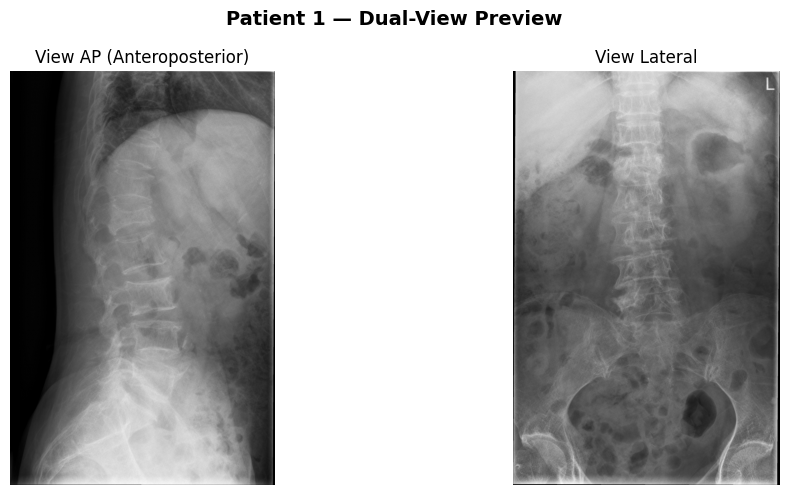

AP shape  : (2988, 1908)
Lat shape : (2993, 1929)


In [7]:
# ── Preview sampel dual-view (sanity check) ───────────────────────────────
def load_image_array(path: str, mode: str = 'npy') -> np.ndarray:
    """Load gambar dari .npy atau .dcm dan kembalikan array 2D grayscale."""
    if mode == 'npy':
        arr = np.load(path)
        if arr.ndim == 3:
            arr = arr[arr.shape[0] // 2]  # ambil slice tengah jika 3D
    else:
        ds = pydicom.dcmread(path, force=True)
        arr = ds.pixel_array
    return arr.astype(np.float32)


if len(img_df) >= 1:
    sample = img_df.iloc[0]
    ap_arr  = load_image_array(sample['image_path_ap'],  IMAGE_MODE)
    lat_arr = load_image_array(sample['image_path_lat'], IMAGE_MODE)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'Patient {sample["patient_id"]} — Dual-View Preview', fontsize=14, fontweight='bold')
    axes[0].imshow(ap_arr,  cmap='gray'); axes[0].set_title('View AP (Anteroposterior)',  fontsize=12)
    axes[1].imshow(lat_arr, cmap='gray'); axes[1].set_title('View Lateral',                fontsize=12)
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()
    print(f'AP shape  : {ap_arr.shape}')
    print(f'Lat shape : {lat_arr.shape}')
else:
    print('⚠️ Tidak ada gambar terindeks.')

### 1.1 · Image Preprocessing Pipeline (Noise Reduction + ROI + Bone Enhancement)
Pipeline: Gaussian Filter → ROI Crop (L1-L4) → Bone Enhancement (CLAHE+Otsu) → Resize → Normalize → RGB

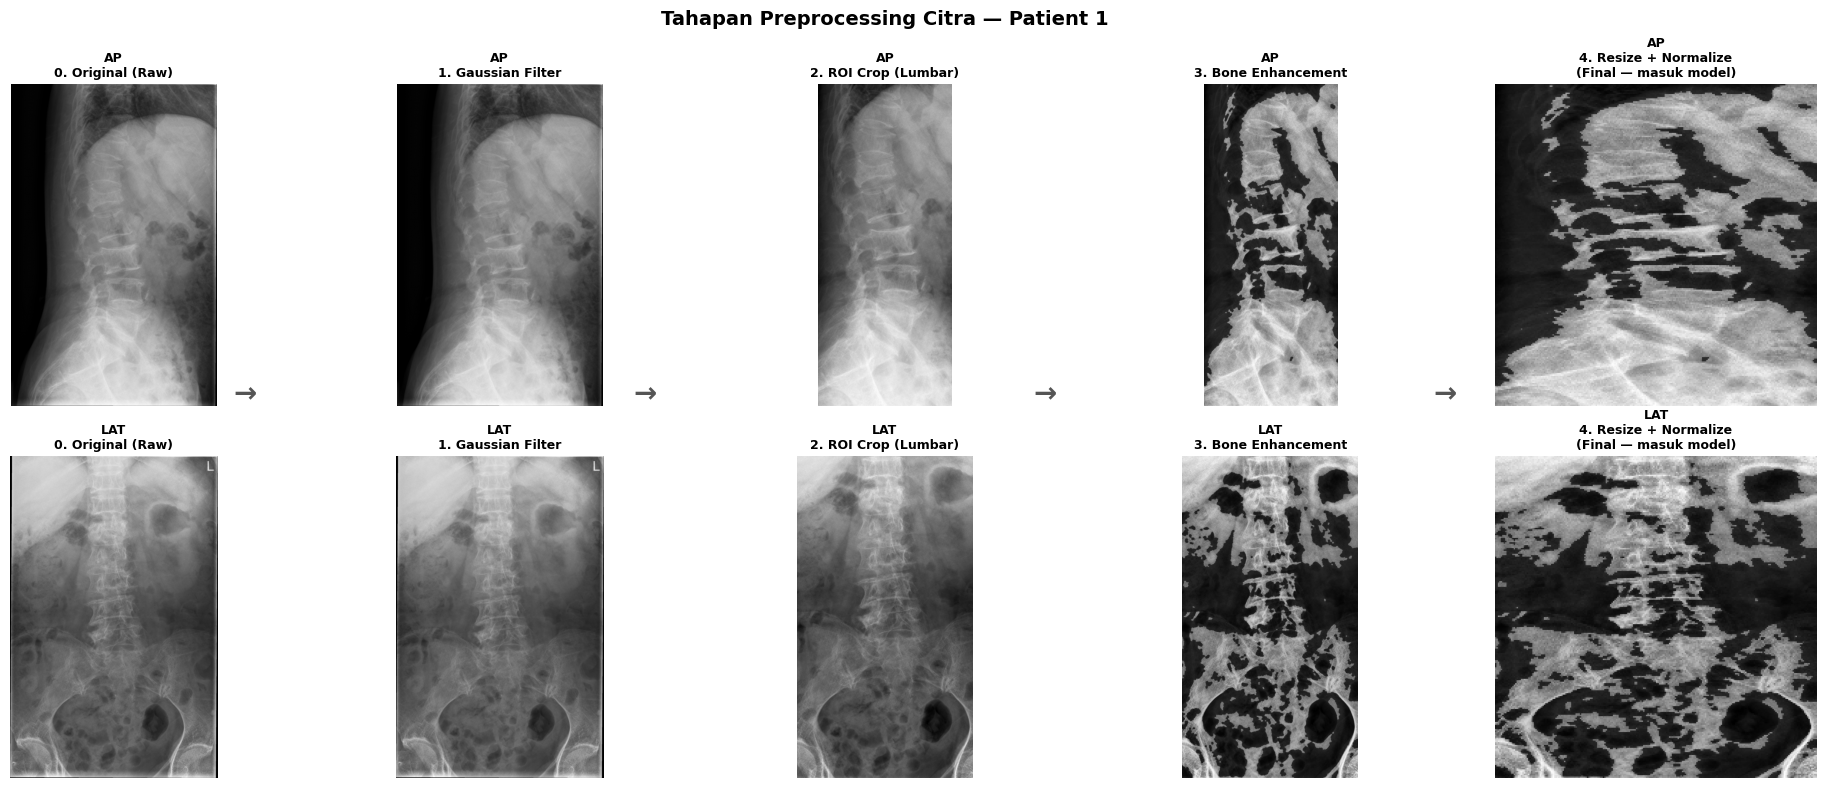

  RINGKASAN TIAP TAHAP (AP) — Patient 1
  0. Original (Raw)                   shape=(2988, 1908)       min=0.00  max=255.00  mean=102.83
  1. Gaussian Filter                  shape=(2988, 1908)       min=0.00  max=253.00  mean=102.84
  2. ROI Crop (Lumbar)                shape=(2570, 1069)       min=32.00  max=236.00  mean=142.36
  3. Bone Enhancement                 shape=(2570, 1069)       min=0.35  max=255.00  mean=112.76
  4. Resize + Normalize               shape=(224, 224)         min=0.00  max=1.00  mean=0.44


In [8]:
# ── ROI Configuration ────────────────────────────────────────────────────
ROI_CONFIG = {
    'ap':  {'top': 0.12, 'bottom': 0.98, 'left': 0.22, 'right': 0.78},
    'lat': {'top': 0.12, 'bottom': 0.98, 'left': 0.12, 'right': 0.85},
}


def apply_gaussian_filter(arr, ksize=GAUSSIAN_KERNEL_SIZE, sigma=GAUSSIAN_SIGMA):
    """Gaussian Blur untuk noise reduction sensor DXA."""
    arr_norm = cv2.normalize(arr, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return cv2.GaussianBlur(arr_norm, ksize, sigma).astype(np.float32)


def crop_lumbar_roi(arr, view='ap'):
    """Crop ROI vertebra lumbal L1-L4 (koordinat persentase)."""
    cfg = ROI_CONFIG.get(view, ROI_CONFIG['ap'])
    h, w = arr.shape[:2]
    r0, r1 = int(h * cfg['top']), int(h * cfg['bottom'])
    c0, c1 = int(w * cfg['left']), int(w * cfg['right'])
    cropped = arr[r0:r1, c0:c1]
    return cropped if cropped.size > 0 else arr


def enhance_bone_region(arr, clip_limit=2.5, tile_size=(8,8), mask_blend=0.65):
    """CLAHE + Otsu masking: tingkatkan kontras tulang, lemahkan soft tissue."""
    if arr.dtype != np.uint8:
        arr_u8 = cv2.normalize(arr, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    else:
        arr_u8 = arr.copy()
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    enhanced = clahe.apply(arr_u8)
    _, bone_mask = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    bone_mask = cv2.morphologyEx(bone_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    bone_mask = cv2.morphologyEx(bone_mask, cv2.MORPH_OPEN,  kernel, iterations=1)
    mask_norm  = bone_mask.astype(np.float32) / 255.0
    soft_blend = mask_norm * mask_blend + (1.0 - mask_blend)
    return enhanced.astype(np.float32) * soft_blend


def augment_image(img):
    """Augmentasi sesuai referensi paper:
    - Rotation ±40°
    - Width/Height shift ±0.2
    - Shear 0.2
    - Horizontal flip
    """
    h, w = img.shape[:2]
    cfg = AUGMENT_CONFIG

    # Rotation ±40°
    angle = np.random.uniform(-cfg['rotation_range'], cfg['rotation_range'])
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

    # Width/Height shift
    dx = np.random.uniform(-cfg['width_shift_range'], cfg['width_shift_range']) * w
    dy = np.random.uniform(-cfg['height_shift_range'], cfg['height_shift_range']) * h
    M = np.float32([[1, 0, dx], [0, 1, dy]])
    img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

    # Shear
    shear = np.random.uniform(-cfg['shear_range'], cfg['shear_range'])
    M = np.float32([[1, shear, 0], [0, 1, 0]])
    img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

    # Horizontal flip (50% chance)
    if cfg['horizontal_flip'] and np.random.random() > 0.5:
        img = cv2.flip(img, 1)

    return img


def preprocess_image(path, mode='npy', target_size=IMG_SIZE,
                     view='ap', apply_filter=True,
                     apply_roi=True, apply_bone=True):
    """Pipeline: Load → Gaussian → ROI Crop → Bone Enhancement → Resize → Normalize → RGB"""
    arr = load_image_array(path, mode)
    if apply_filter:
        arr = apply_gaussian_filter(arr)
    if apply_roi:
        arr = crop_lumbar_roi(arr, view=view)
    if apply_bone:
        arr = enhance_bone_region(arr)
    arr_resized = cv2.resize(arr, target_size, interpolation=cv2.INTER_LINEAR)
    arr_norm = arr_resized / 255.0 if arr_resized.max() > 1.0 else arr_resized
    arr_norm = arr_norm.astype(np.float32)
    if arr_norm.ndim == 2:
        arr_rgb = np.stack([arr_norm] * 3, axis=-1)
    else:
        arr_rgb = arr_norm
    return arr_rgb


# ── Visualisasi: Setiap Tahap Preprocessing Dipisah ──────────────────────
if len(img_df) >= 1:
    sample = img_df.iloc[0]

    def run_pipeline_stepwise(path, mode, view):
        """Jalankan preprocess_image() tahap demi tahap, simpan hasil tiap step."""
        stages = {}

        # Stage 0: Raw
        arr = load_image_array(path, mode)
        stages['0. Original (Raw)'] = arr.copy()

        # Stage 1: Gaussian filter
        arr = apply_gaussian_filter(arr)
        stages['1. Gaussian Filter'] = arr.copy()

        # Stage 2: ROI crop (vertebra lumbal)
        arr = crop_lumbar_roi(arr, view=view)
        stages['2. ROI Crop (Lumbar)'] = arr.copy()

        # Stage 3: Bone enhancement (CLAHE + Otsu mask)
        arr = enhance_bone_region(arr)
        stages['3. Bone Enhancement'] = arr.copy()

        # Stage 4: Resize + normalize (hasil akhir masuk model)
        arr_resized = cv2.resize(arr, IMG_SIZE, interpolation=cv2.INTER_LINEAR)
        arr_norm = arr_resized / 255.0 if arr_resized.max() > 1.0 else arr_resized
        stages['4. Resize + Normalize\n(Final — masuk model)'] = arr_norm.astype(np.float32)

        return stages


    # ── Jalankan untuk AP dan Lateral ─────────────────────────────────────
    stages_ap  = run_pipeline_stepwise(sample['image_path_ap'],  IMAGE_MODE, 'ap')
    stages_lat = run_pipeline_stepwise(sample['image_path_lat'], IMAGE_MODE, 'lat')

    n_stages = len(stages_ap)
    fig, axes = plt.subplots(2, n_stages, figsize=(4*n_stages, 8))
    fig.suptitle(f'Tahapan Preprocessing Citra — Patient {sample["patient_id"]}',
                fontsize=14, fontweight='bold')

    for col, (stage_name, img) in enumerate(stages_ap.items()):
        axes[0, col].imshow(img, cmap='gray')
        axes[0, col].set_title(f'AP\n{stage_name}', fontsize=9, fontweight='bold')
        axes[0, col].axis('off')

    for col, (stage_name, img) in enumerate(stages_lat.items()):
        axes[1, col].imshow(img, cmap='gray')
        axes[1, col].set_title(f'LAT\n{stage_name}', fontsize=9, fontweight='bold')
        axes[1, col].axis('off')

    # Panah antar tahap
    for col in range(n_stages - 1):
        fig.text((col+1)/n_stages - 0.02, 0.5, '→', fontsize=20,
                 ha='center', va='center', fontweight='bold', color='#555')

    plt.tight_layout()
    plt.savefig(str(MODEL_DIR / 'preprocessing_steps_separated.png'),
               dpi=150, bbox_inches='tight')
    plt.show()

    # ── Info bentuk & statistik tiap tahap ────────────────────────────────
    print("="*70)
    print(f"  RINGKASAN TIAP TAHAP (AP) — Patient {sample['patient_id']}")
    print("="*70)
    for stage_name, img in stages_ap.items():
        print(f"  {stage_name.splitlines()[0]:35} shape={str(img.shape):18} "
              f"min={img.min():.2f}  max={img.max():.2f}  mean={img.mean():.2f}")

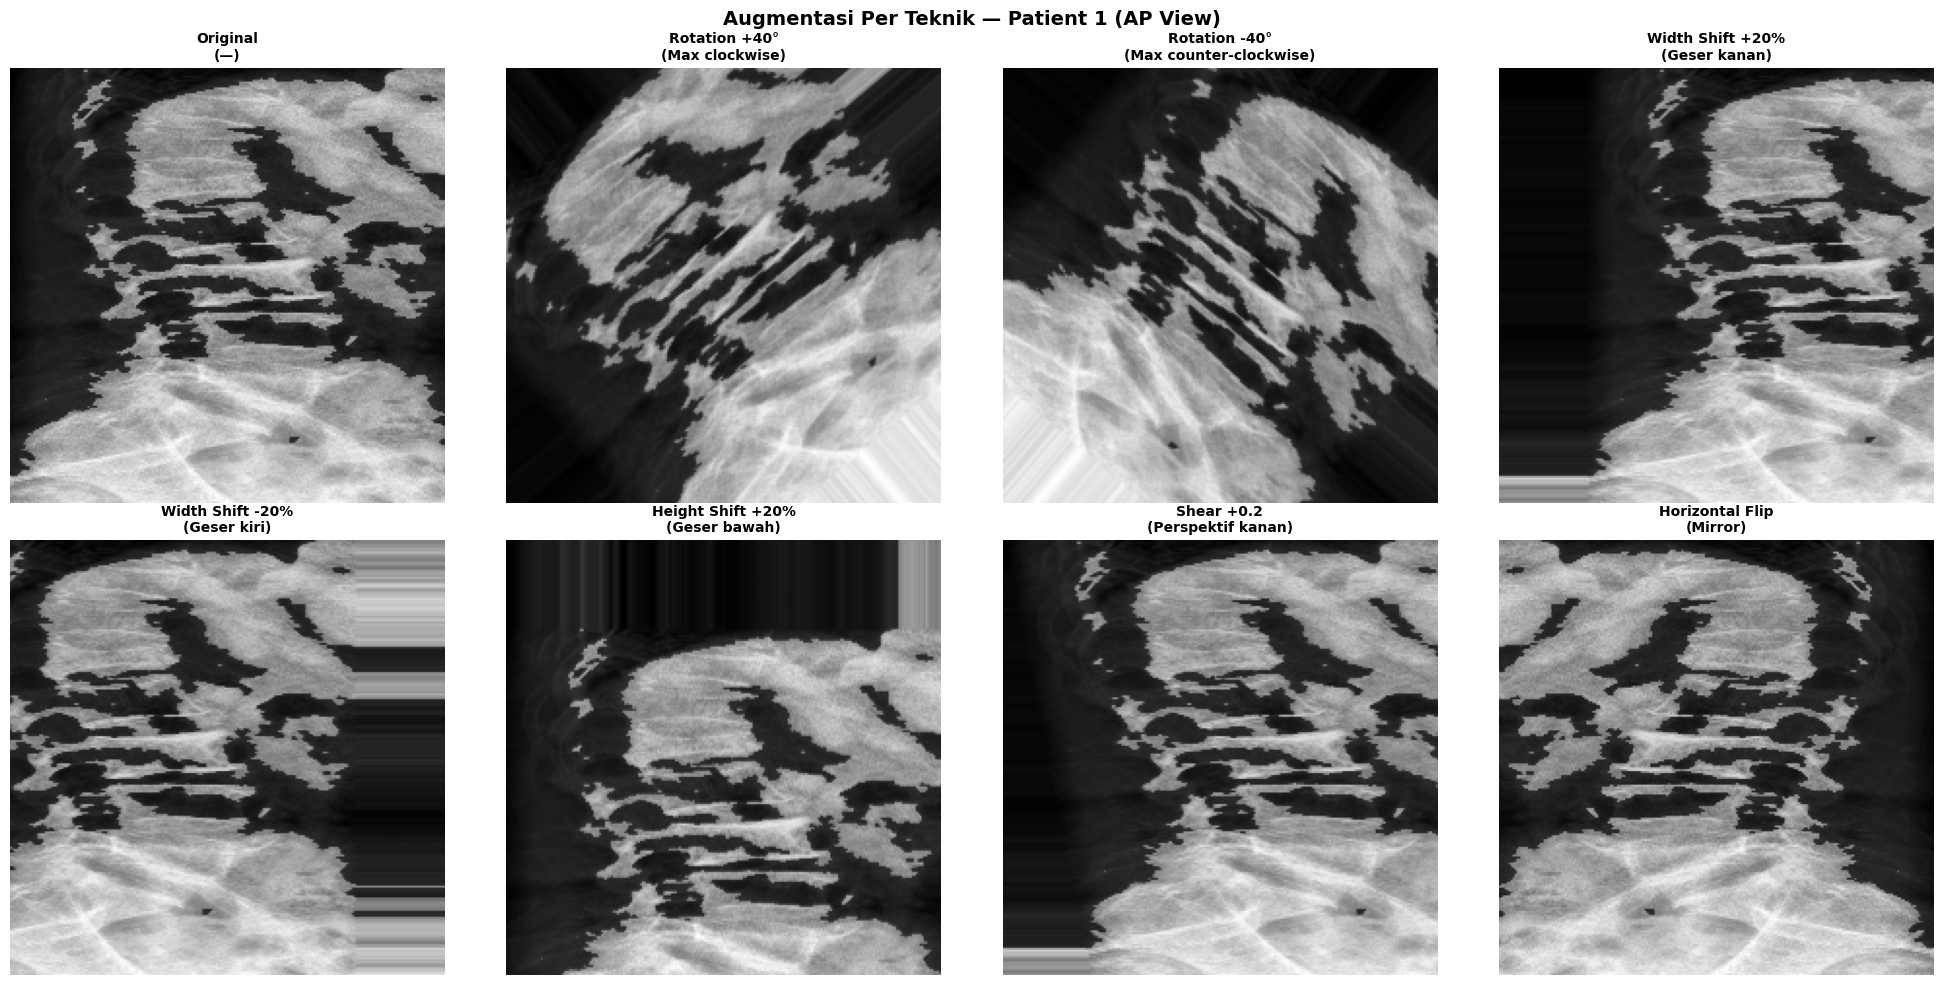

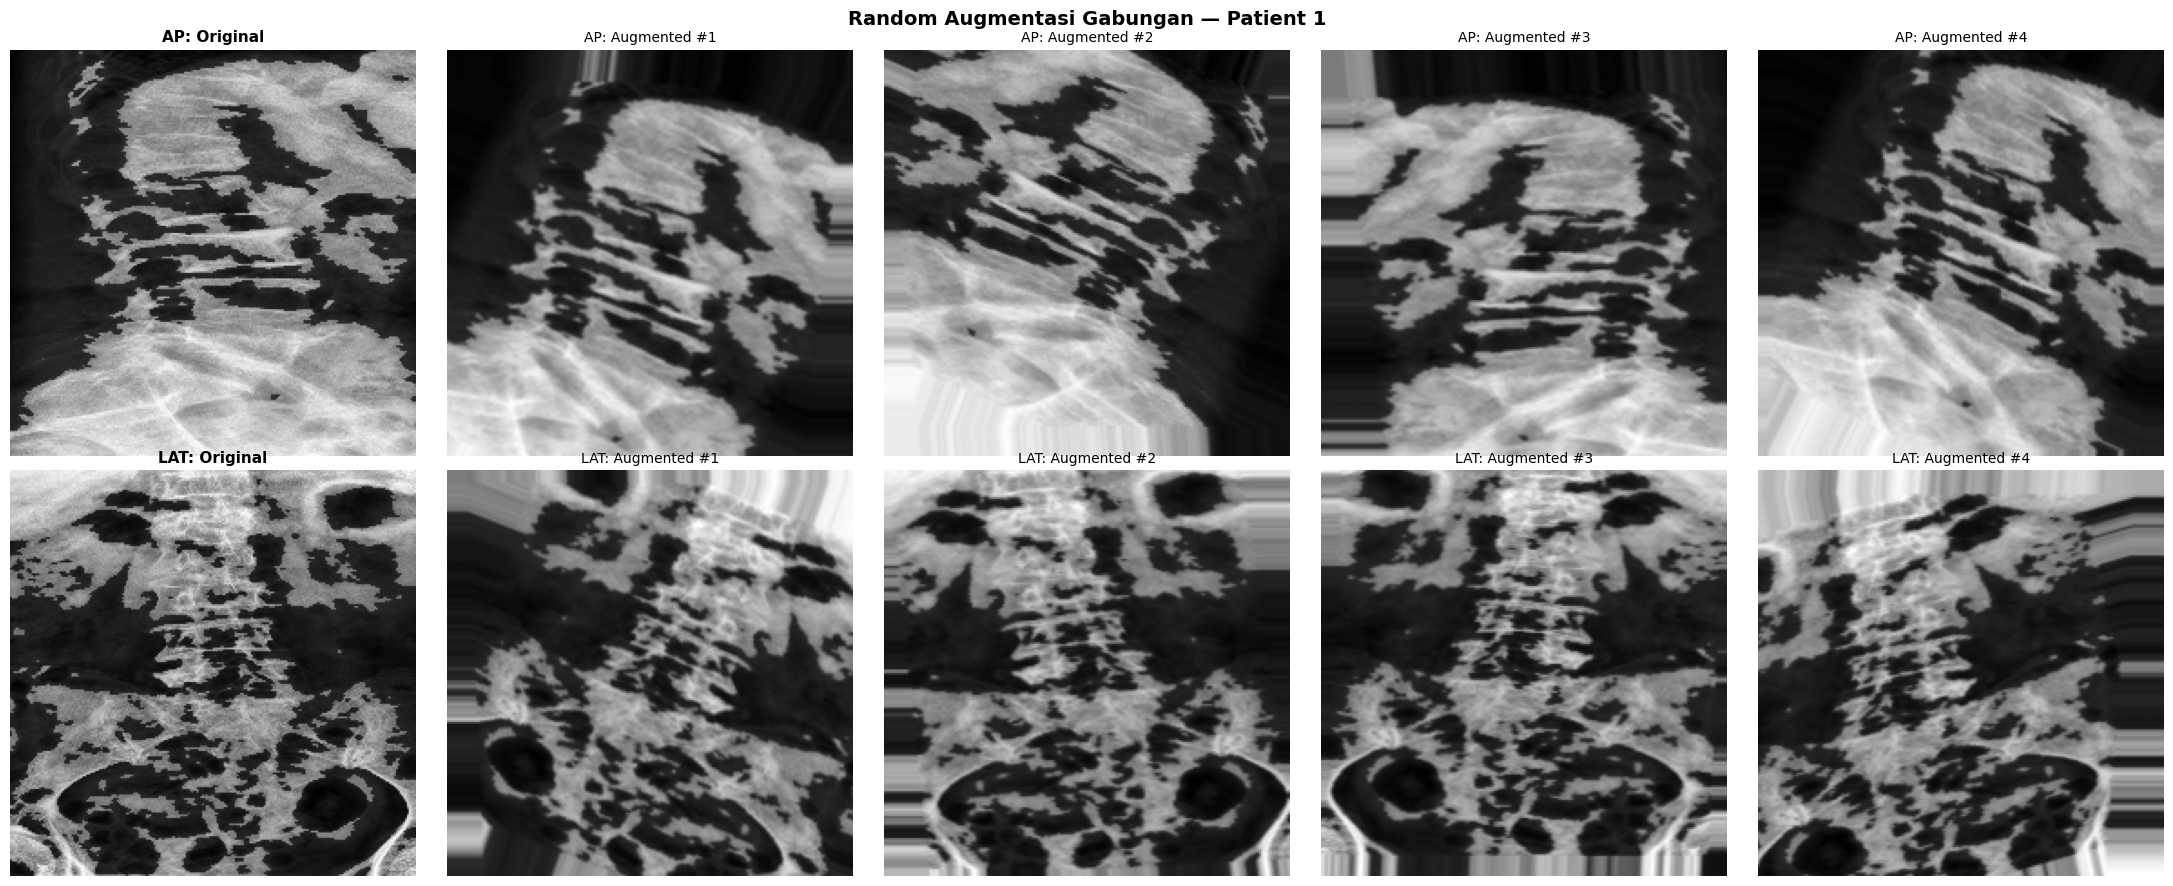

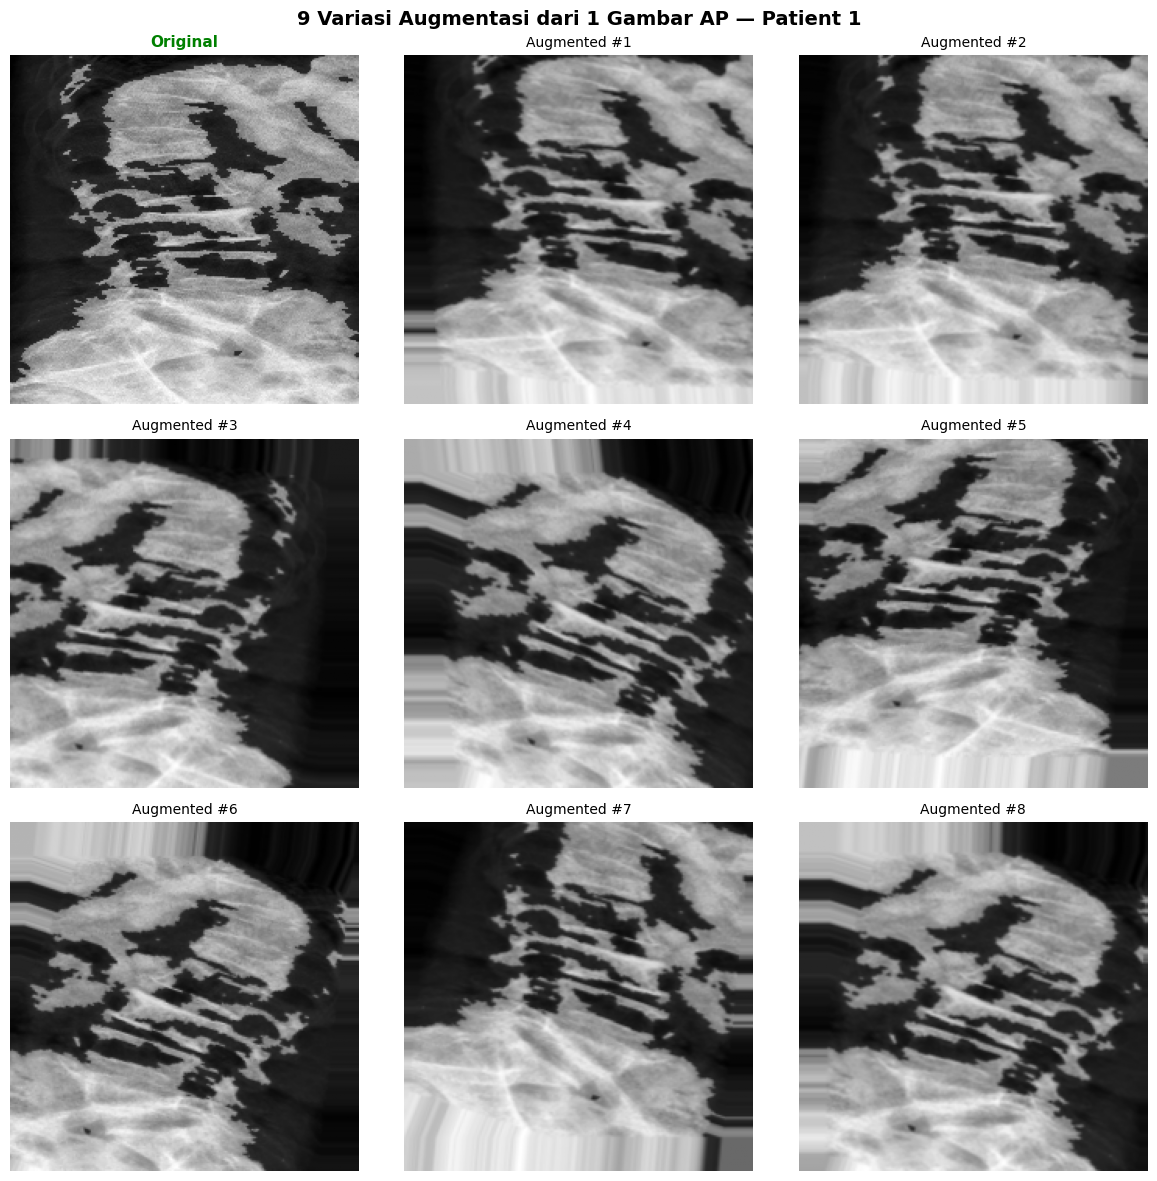

Augmentation Config:
  rotation_range           : 25
  width_shift_range        : 0.1
  height_shift_range       : 0.1
  shear_range              : 0.12
  horizontal_flip          : True
  vertical_flip            : False

✅ Augmentasi hanya diterapkan pada TRAINING set.
   Validation dan Test TIDAK di-augmentasi.


In [9]:
# ══════════════════════════════════════════════════════════════════════════
#  VISUALISASI AUGMENTASI — Per Teknik + Gabungan
# ══════════════════════════════════════════════════════════════════════════

sample = img_df.iloc[0]
img_ap  = preprocess_image(sample['image_path_ap'],  IMAGE_MODE, view='ap')
img_lat = preprocess_image(sample['image_path_lat'], IMAGE_MODE, view='lat')


def augment_rotation(img, angle=40):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

def augment_shift(img, dx_frac=0.2, dy_frac=0.2):
    h, w = img.shape[:2]
    M = np.float32([[1, 0, dx_frac*w], [0, 1, dy_frac*h]])
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

def augment_shear(img, shear=0.2):
    h, w = img.shape[:2]
    M = np.float32([[1, shear, 0], [0, 1, 0]])
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

def augment_hflip(img):
    return cv2.flip(img, 1)


# ══════════════════════════════════════════════════════════════════════════
#  FIGURE 1: Per-Teknik (AP view)
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(f'Augmentasi Per Teknik — Patient {sample["patient_id"]} (AP View)',
             fontsize=14, fontweight='bold')

techniques = [
    (img_ap,                                  'Original',               '—'),
    (augment_rotation(img_ap, +40),           'Rotation +40°',          'Max clockwise'),
    (augment_rotation(img_ap, -40),           'Rotation -40°',          'Max counter-clockwise'),
    (augment_shift(img_ap, 0.2, 0),           'Width Shift +20%',       'Geser kanan'),
    (augment_shift(img_ap, -0.2, 0),          'Width Shift -20%',       'Geser kiri'),
    (augment_shift(img_ap, 0, 0.2),           'Height Shift +20%',      'Geser bawah'),
    (augment_shear(img_ap, 0.2),              'Shear +0.2',             'Perspektif kanan'),
    (augment_hflip(img_ap),                   'Horizontal Flip',        'Mirror'),
]

for idx, (img, title, desc) in enumerate(techniques):
    row, col = divmod(idx, 4)
    ax = axes[row, col]
    ax.imshow(img[:,:,0] if img.ndim == 3 else img, cmap='gray')
    ax.set_title(f'{title}\n({desc})', fontsize=10, fontweight='bold')
    ax.axis('off')
    if idx > 0:
        ax.patch.set_edgecolor('#e74c3c')
        ax.patch.set_linewidth(2)

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'augmentation_per_technique.png'), dpi=150, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════════
#  FIGURE 2: Random Augmentasi Gabungan (AP + LAT, 4 sampel)
# ══════════════════════════════════════════════════════════════════════════
np.random.seed(None)  # random setiap kali

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle(f'Random Augmentasi Gabungan — Patient {sample["patient_id"]}',
             fontsize=14, fontweight='bold')

# Row 0: AP
axes[0, 0].imshow(img_ap[:,:,0], cmap='gray')
axes[0, 0].set_title('AP: Original', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

for i in range(1, 5):
    aug = augment_image(img_ap.copy())
    axes[0, i].imshow(aug[:,:,0], cmap='gray')
    axes[0, i].set_title(f'AP: Augmented #{i}', fontsize=10)
    axes[0, i].axis('off')

# Row 1: LAT
axes[1, 0].imshow(img_lat[:,:,0], cmap='gray')
axes[1, 0].set_title('LAT: Original', fontsize=11, fontweight='bold')
axes[1, 0].axis('off')

for i in range(1, 5):
    aug = augment_image(img_lat.copy())
    axes[1, i].imshow(aug[:,:,0], cmap='gray')
    axes[1, i].set_title(f'LAT: Augmented #{i}', fontsize=10)
    axes[1, i].axis('off')

# Border original
for ax in [axes[0,0], axes[1,0]]:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#2ecc71')
        spine.set_linewidth(3)

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'augmentation_random_samples.png'), dpi=150, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════════
#  FIGURE 3: Grid 3×3 — Variasi augmentasi dari 1 gambar AP
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle(f'9 Variasi Augmentasi dari 1 Gambar AP — Patient {sample["patient_id"]}',
             fontsize=14, fontweight='bold')

for i in range(9):
    row, col = divmod(i, 3)
    ax = axes[row, col]
    if i == 0:
        ax.imshow(img_ap[:,:,0], cmap='gray')
        ax.set_title('Original', fontsize=11, fontweight='bold', color='green')
        for spine in ax.spines.values():
            spine.set_visible(True); spine.set_color('#2ecc71'); spine.set_linewidth(3)
    else:
        aug = augment_image(img_ap.copy())
        ax.imshow(aug[:,:,0], cmap='gray')
        ax.set_title(f'Augmented #{i}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'augmentation_grid_9.png'), dpi=150, bbox_inches='tight')
plt.show()


# ── Print konfigurasi ────────────────────────────────────────────────────
print('Augmentation Config:')
for k, v in AUGMENT_CONFIG.items():
    print(f'  {k:25}: {v}')
print(f'\n✅ Augmentasi hanya diterapkan pada TRAINING set.')
print(f'   Validation dan Test TIDAK di-augmentasi.')

## Patient Data
Memuat dan membersihkan data klinis dari file Excel.


In [10]:
# ── Load Clinical Data ────────────────────────────────────────────────────
raw = pd.read_excel(CLINICAL_XLSX)
raw.columns = (
    raw.columns.str.strip().str.lower()
    .str.replace(' ', '_').str.replace('-', '_')
)
print(f'Sumber   : {CLINICAL_XLSX}')
print(f'Raw shape: {raw.shape}')
print(f'Columns  : {list(raw.columns)}')
display(raw.head(3))


Sumber   : /kaggle/input/datasets/damarsyarafiramadhan/lumos-data/lumos_clinical_data.xlsx
Raw shape: (803, 52)
Columns  : ['patient_id', 'age', 'gender', 'ethnicity', 'height', 'weight', 'bmi', 'osteoporosis', 'bmd', 'bmd_l1_l2', 'bmd_l1_l3', 'bmd_l1_l4', 'bmd_l2_l3', 'bmd_l2_l4', 'bmd_l3_l4', 'bmc_l1_l2', 'bmc_l1_l3', 'bmc_l1_l4', 'bmc_l2_l3', 'bmc_l2_l4', 'bmc_l3_l4', 's_l1_l2', 's_l1_l3', 's_l1_l4', 's_l2_l3', 's_l2_l4', 's_l3_l4', 't_value', 't_l1_l2', 't_l1_l3', 't_l1_l4', 't_l2_l3', 't_l2_l4', 't_l3_l4', 'z_l1_l2', 'z_l1_l3', 'z_l1_l4', 'z_l2_l3', 'z_l2_l4', 'z_l3_l4', 'avgh_l1_l2', 'avgh_l1_l3', 'avgh_l1_l4', 'avgh_l2_l3', 'avgh_l2_l4', 'avgh_l3_l4', 'avgw_l1_l2', 'avgw_l1_l3', 'avgw_l1_l4', 'avgw_l2_l3', 'avgw_l2_l4', 'avgw_l3_l4']


,patient_id,age,gender,ethnicity,height,weight,bmi,osteoporosis,bmd,bmd_l1_l2,...,avgh_l1_l4,avgh_l2_l3,avgh_l2_l4,avgh_l3_l4,avgw_l1_l2,avgw_l1_l3,avgw_l1_l4,avgw_l2_l3,avgw_l2_l4,avgw_l3_l4
0,1,68,Female,Asian,1.64,61.0,22.679952,2,0.741,0.662,...,12.65,6.68,9.83,6.59,3.90,3.90,4.02,3.78,3.98,4.14
1,2,30,Female,Asian,1.56,45.0,18.491124,1,0.940,0.925,...,14.29,7.14,10.93,7.25,3.42,3.49,3.66,3.53,3.75,3.91
2,3,59,Female,Asian,1.59,66.0,26.106562,0,1.019,0.860,...,13.23,6.69,10.07,6.64,3.81,4.01,4.20,4.16,4.36,4.58


In [11]:
# Statistik deskriptif
print('=== df.describe() ===')
display(raw.describe(include='all').T)
print(f'\n=== df.info() ===')
raw.info()
print(f'\nDuplikasi: {raw.duplicated().sum()}')
print(f'Missing values (total): {raw.isnull().sum().sum()}')


=== df.describe() ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
patient_id,803.0,NaN,NaN,NaN,402.0,231.950426,1.0,201.5,402.0,602.5,803.0
age,803.0,NaN,NaN,NaN,63.864259,12.427255,14.0,58.0,65.0,72.0,93.0
gender,803,2,Female,648,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ethnicity,803,1,Asian,803,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height,803.0,NaN,NaN,NaN,1.580367,0.074156,1.38,1.53,1.58,1.63,1.85
weight,803.0,NaN,NaN,NaN,58.66127,10.802718,29.0,51.5,58.0,65.0,120.0
bmi,803.0,NaN,NaN,NaN,23.448219,3.764111,12.42049,20.899799,23.148148,25.449731,50.598752
osteoporosis,803.0,NaN,NaN,NaN,0.917808,0.794758,0.0,0.0,1.0,2.0,2.0
bmd,803.0,NaN,NaN,NaN,0.949221,0.209905,0.48,0.803,0.925,1.0625,1.964756
bmd_l1_l2,803.0,NaN,NaN,NaN,0.892985,0.196068,0.423,0.751,0.874,0.999,1.659



=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 803 entries, 0 to 802
Data columns (total 52 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    803 non-null    int64  
 1   age           803 non-null    int64  
 2   gender        803 non-null    object 
 3   ethnicity     803 non-null    object 
 4   height        803 non-null    float64
 5   weight        803 non-null    float64
 6   bmi           803 non-null    float64
 7   osteoporosis  803 non-null    int64  
 8   bmd           803 non-null    float64
 9   bmd_l1_l2     803 non-null    float64
 10  bmd_l1_l3     803 non-null    float64
 11  bmd_l1_l4     803 non-null    float64
 12  bmd_l2_l3     803 non-null    float64
 13  bmd_l2_l4     803 non-null    float64
 14  bmd_l3_l4     803 non-null    float64
 15  bmc_l1_l2     803 non-null    float64
 16  bmc_l1_l3     803 non-null    float64
 17  bmc_l1_l4     803 non-null    float64
 18  bmc_l2_l3  

## EDA


### Target Var Distribution
Distribusi kelas target (`osteoporosis`) — periksa ketidakseimbangan kelas sebelum modelling.


Kolom target terdeteksi: "osteoporosis"

Distribusi kelas:
  normal           289  █████████████████████████████
  osteopenia       291  ██████████████████████████████
  osteoporosis     223  ██████████████████████


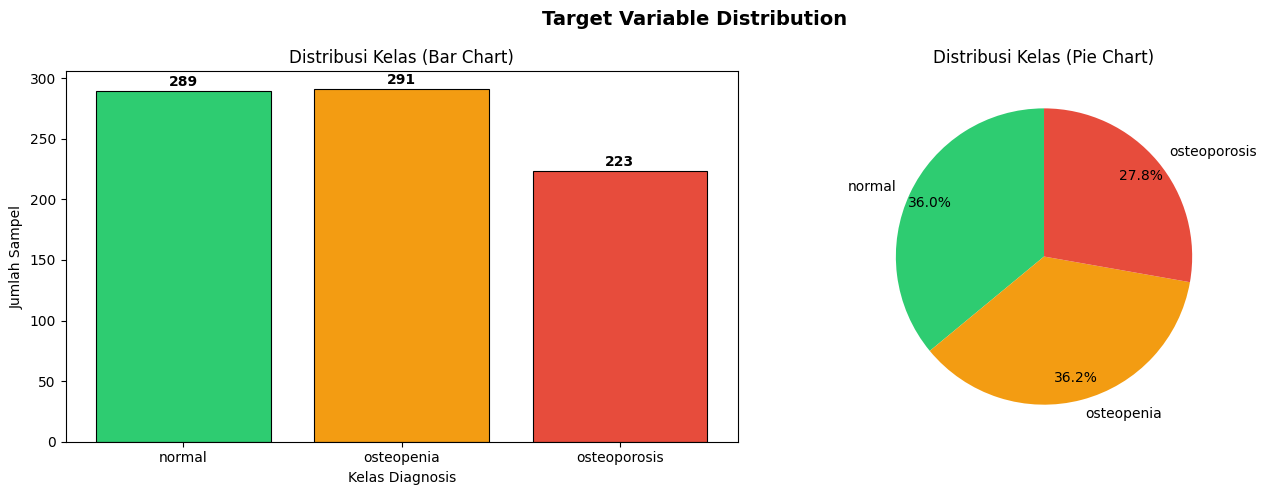

In [12]:
label_col = next(
    (c for c in raw.columns if c in ('osteoporosis', 'diagnosis', 'label')),
    raw.columns[-1]
)
print(f'Kolom target terdeteksi: "{label_col}"')

# ── Mapping kode → nama label (fallback aman kalau CLASS_NAMES belum ada) ──
try:
    label_names_map = {i: name for i, name in enumerate(CLASS_NAMES)}
except NameError:
    label_names_map = {0: 'normal', 1: 'osteopenia', 2: 'osteoporosis'}

dist = raw[label_col].value_counts().sort_index()
dist_named = dist.rename(index=lambda k: label_names_map.get(int(k), str(k)))

print('\nDistribusi kelas:')
for k, v in dist_named.items():
    bar = '█' * int(v / dist_named.max() * 30)
    print(f'  {str(k):15} {v:4d}  {bar}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')

class_colors = ['#2ecc71', '#f39c12', '#e74c3c'][:len(dist_named)]

# ── Bar chart — sekarang pakai NAMA label ────────────────────────────────
bars = ax1.bar(dist_named.index, dist_named.values,
               color=class_colors, edgecolor='black', linewidth=0.8)
ax1.set_xlabel('Kelas Diagnosis')
ax1.set_ylabel('Jumlah Sampel')
ax1.set_title('Distribusi Kelas (Bar Chart)')
for bar, val in zip(bars, dist_named.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(val), ha='center', va='bottom', fontweight='bold')

# ── Pie chart — sekarang pakai NAMA label ────────────────────────────────
ax2.pie(dist_named.values, labels=dist_named.index,
        colors=class_colors, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
ax2.set_title('Distribusi Kelas (Pie Chart)')

plt.tight_layout()
plt.show()

  SKEWNESS DISTRIBUTION — Fitur Numerik Klinis


,feature,skewness,interpretation,arah
3,bmi,1.030,sangat skew,kanan (right-tailed)
0,age,-1.005,sangat skew,kiri (left-tailed)
2,weight,0.979,moderat skew,kanan (right-tailed)
1,height,0.415,simetris,kanan (right-tailed)


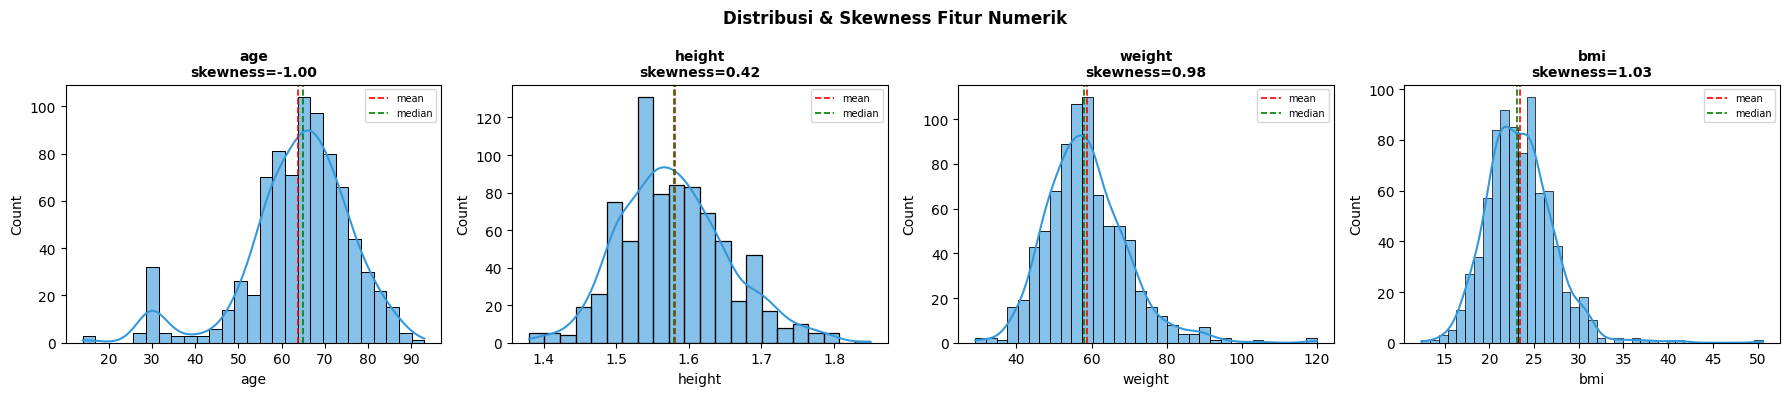


Catatan: |skewness| > 1 → pertimbangkan transformasi (log/sqrt) sebelum StandardScaler, karena distribusi sangat asimetris bisa mempengaruhi performa scaler linear.


In [13]:
from scipy.stats import skew

print("="*65)
print("  SKEWNESS DISTRIBUTION — Fitur Numerik Klinis")
print("="*65)

skew_results = []
for col in NUM_FEATURES:
    if col in raw.columns:
        vals = pd.to_numeric(raw[col], errors='coerce').dropna()
        s = skew(vals)
        interpretation = ("simetris" if abs(s) < 0.5 else
                          "moderat skew" if abs(s) < 1.0 else
                          "sangat skew")
        arah = "kanan (right-tailed)" if s > 0 else "kiri (left-tailed)" if s < 0 else "-"
        skew_results.append({'feature': col, 'skewness': s,
                             'interpretation': interpretation, 'arah': arah})

skew_df = pd.DataFrame(skew_results).sort_values('skewness', key=abs, ascending=False)
display(skew_df.round(3))

# ── Visualisasi distribusi + garis skewness ────────────────────────────
fig, axes = plt.subplots(1, len(NUM_FEATURES), figsize=(4.5*len(NUM_FEATURES), 4))
if len(NUM_FEATURES) == 1:
    axes = [axes]

for ax, col in zip(axes, NUM_FEATURES):
    if col in raw.columns:
        vals = pd.to_numeric(raw[col], errors='coerce').dropna()
        sns.histplot(vals, kde=True, ax=ax, color='#3498DB', alpha=0.6)
        s = skew(vals)
        ax.axvline(vals.mean(), color='red', ls='--', lw=1.2, label=f'mean')
        ax.axvline(vals.median(), color='green', ls='--', lw=1.2, label=f'median')
        ax.set_title(f'{col}\nskewness={s:.2f}', fontweight='bold', fontsize=10)
        ax.legend(fontsize=7)

plt.suptitle('Distribusi & Skewness Fitur Numerik', fontweight='bold')
plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'skewness_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nCatatan: |skewness| > 1 → pertimbangkan transformasi (log/sqrt) "
      "sebelum StandardScaler, karena distribusi sangat asimetris bisa "
      "mempengaruhi performa scaler linear.")

  ANALISIS AGE GROUP vs DIAGNOSIS


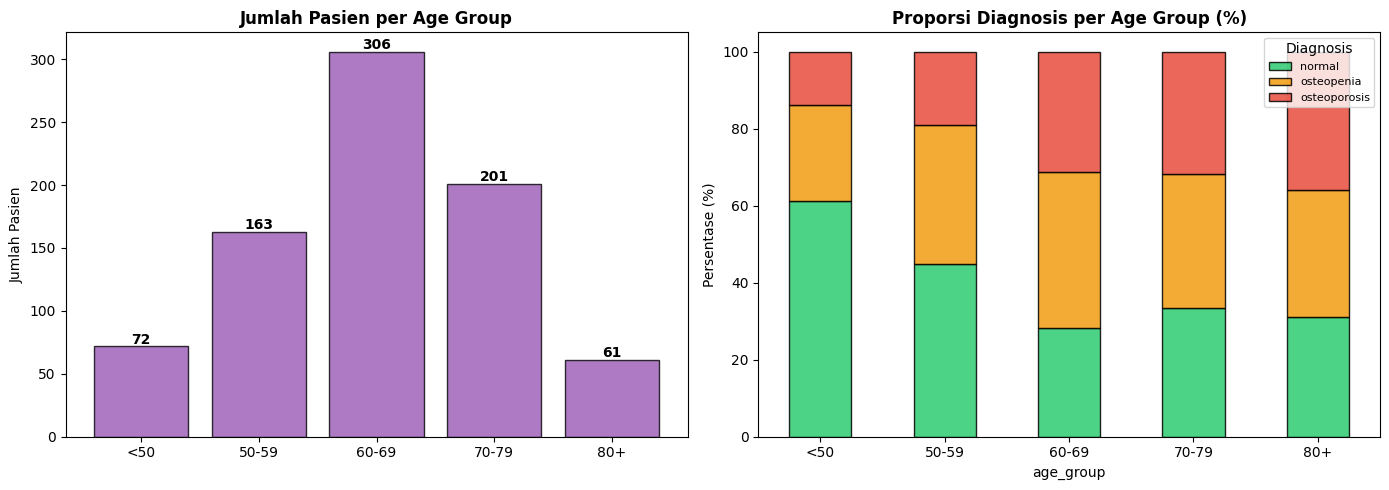


Tabel Proporsi Diagnosis per Age Group:


,normal,osteopenia,osteoporosis
age_group,,,
<50,61.1,25.0,13.9
50-59,44.8,36.2,19.0
60-69,28.1,40.5,31.4
70-79,33.3,34.8,31.8
80+,31.1,32.8,36.1



Chi-square test (age_group vs diagnosis): χ²=40.21, p=2.9282e-06  (✓ signifikan)


In [14]:
print("="*65)
print("  ANALISIS AGE GROUP vs DIAGNOSIS")
print("="*65)

AGE_BINS   = [0, 50, 60, 70, 80, 150]
AGE_LABELS = ['<50', '50-59', '60-69', '70-79', '80+']

raw['age_group'] = pd.cut(pd.to_numeric(raw['age'], errors='coerce'),
                          bins=AGE_BINS, labels=AGE_LABELS, right=False)

# ── Distribusi jumlah pasien per age group ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_counts = raw['age_group'].value_counts().reindex(AGE_LABELS)
axes[0].bar(AGE_LABELS, age_counts.values, color='#9b59b6', alpha=0.8, edgecolor='black')
for i, v in enumerate(age_counts.values):
    axes[0].text(i, v + 2, str(int(v)), ha='center', fontweight='bold')
axes[0].set_title('Jumlah Pasien per Age Group', fontweight='bold')
axes[0].set_ylabel('Jumlah Pasien')

# ── Proporsi diagnosis per age group (stacked bar, %) ───────────────────
cross = pd.crosstab(raw['age_group'], raw[label_col], normalize='index') * 100
cross.columns = [CLASS_NAMES[int(c)] for c in cross.columns]
cross = cross.reindex(AGE_LABELS)
cross.plot(kind='bar', stacked=True, ax=axes[1],
          color=['#2ecc71', '#f39c12', '#e74c3c'][:cross.shape[1]],
          edgecolor='black', alpha=0.85)
axes[1].set_title('Proporsi Diagnosis per Age Group (%)', fontweight='bold')
axes[1].set_ylabel('Persentase (%)')
axes[1].legend(title='Diagnosis', fontsize=8)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'age_group_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nTabel Proporsi Diagnosis per Age Group:")
display(cross.round(1))

# ── Chi-square test: apakah age_group berasosiasi signifikan dgn diagnosis? ──
from scipy.stats import chi2_contingency
contingency = pd.crosstab(raw['age_group'], raw[label_col])
chi2_stat, p_val, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square test (age_group vs diagnosis): "
      f"χ²={chi2_stat:.2f}, p={p_val:.4e}  "
      f"({'✓ signifikan' if p_val < 0.05 else '✗ tidak signifikan'})")

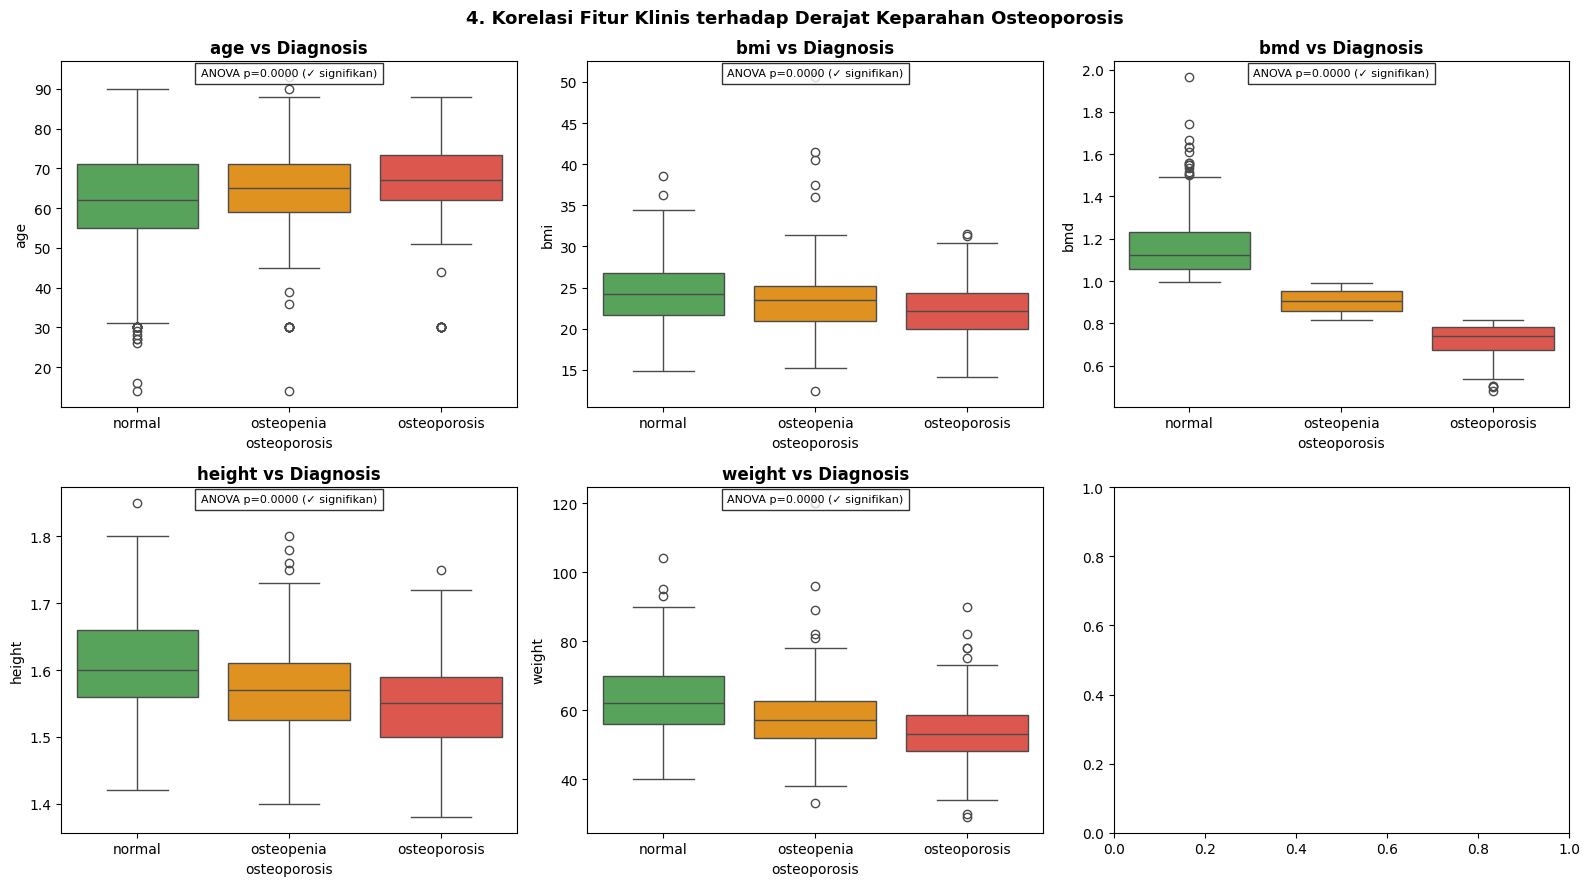


Ringkasan Uji ANOVA (H0: rata-rata sama antar kelas diagnosis):


,feature,f_stat,p_value,significant
2,bmd,1130.100190,8.630757e-234,True
4,weight,63.843578,1.885286e-26,True
3,height,49.465459,5.565030e-21,True
1,bmi,23.556022,1.147234e-10,True
0,age,13.919215,1.142251e-06,True


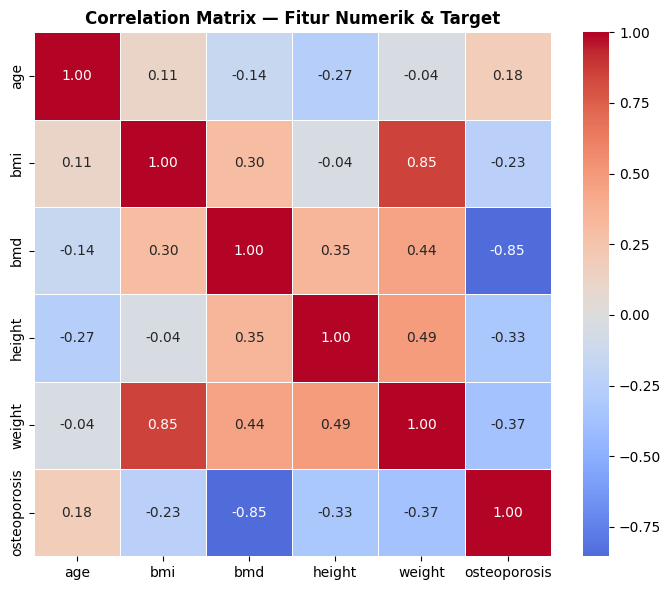


Fitur paling berkorelasi dengan target (osteoporosis):


bmd      -0.854394
weight   -0.370680
height   -0.325510
bmi      -0.233381
age       0.181546
Name: osteoporosis, dtype: float64

In [15]:
from scipy import stats

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('4. Korelasi Fitur Klinis terhadap Derajat Keparahan Osteoporosis',
             fontsize=13, fontweight='bold')

numeric_feats = [c for c in ['age','bmi','bmd','height','weight'] if c in raw.columns]

# ── Boxplot per fitur numerik terhadap label ──────────────────────
for ax, col in zip(axes.flat[:5], numeric_feats):
    sns.boxplot(data=raw, x=label_col, y=col, ax=ax,
               palette=['#4CAF50','#FF9800','#F44336'])
    ax.set_xticklabels(CLASS_NAMES[:len(ax.get_xticklabels())])
    ax.set_title(f'{col} vs Diagnosis', fontweight='bold')

    # ANOVA test (apakah rata-rata beda signifikan antar kelas)
    groups = [raw[raw[label_col]==c][col].dropna() for c in sorted(raw[label_col].unique())]
    if all(len(g) > 1 for g in groups):
        f_stat, p_val = stats.f_oneway(*groups)
        sig = '✓ signifikan' if p_val < 0.05 else '✗ tidak signifikan'
        ax.text(0.5, 0.98, f'ANOVA p={p_val:.4f} ({sig})',
               transform=ax.transAxes, ha='center', va='top', fontsize=8,
               bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# ── Ringkasan ANOVA semua fitur ────────────────────────────────────
print("\nRingkasan Uji ANOVA (H0: rata-rata sama antar kelas diagnosis):")
anova_results = []
for col in numeric_feats:
    groups = [raw[raw[label_col]==c][col].dropna() for c in sorted(raw[label_col].unique())]
    if all(len(g) > 1 for g in groups):
        f_stat, p_val = stats.f_oneway(*groups)
        anova_results.append({'feature': col, 'f_stat': f_stat, 'p_value': p_val,
                              'significant': p_val < 0.05})
anova_df = pd.DataFrame(anova_results).sort_values('f_stat', ascending=False)
display(anova_df)

# ── Correlation matrix numerik ─────────────────────────────────────
corr_cols = numeric_feats + [label_col]
if len(corr_cols) > 1:
    plt.figure(figsize=(7, 6))
    corr = raw[corr_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
               linewidths=0.5)
    plt.title('Correlation Matrix — Fitur Numerik & Target', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\nFitur paling berkorelasi dengan target ({label_col}):")
    target_corr = corr[label_col].drop(label_col).sort_values(key=abs, ascending=False)
    display(target_corr)

### Matrix Correlation
Matriks korelasi Pearson untuk semua fitur numerik — membantu identifikasi multikolinearitas.


### Feature Correlation
Korelasi setiap fitur numerik terhadap variabel target (numerik) — diurutkan dari yang terkuat.


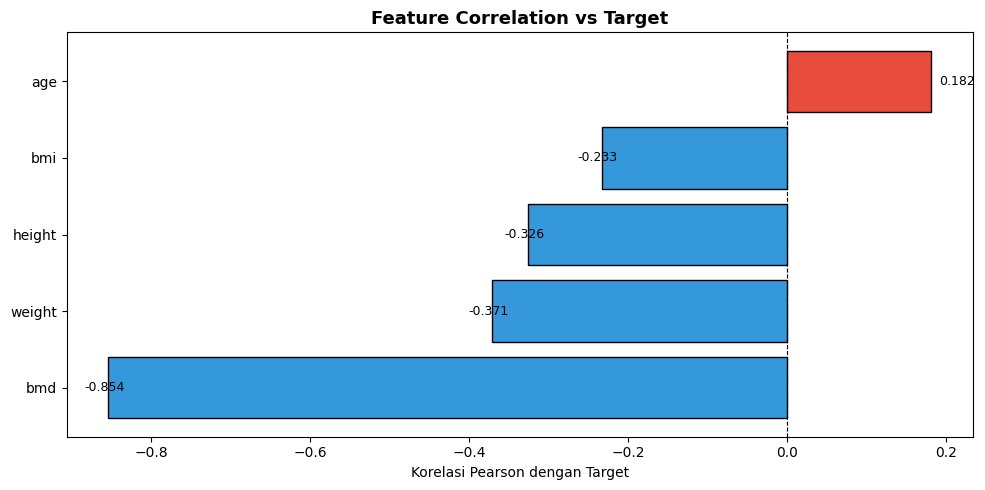

In [16]:
# Encode target numerik untuk keperluan korelasi
target_num = raw[label_col].map(LABEL_MAP) if raw[label_col].dtype == object else raw[label_col]
corr_with_target = raw[numeric_feats].corrwith(target_num).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, max(5, len(numeric_feats)//2)))
colors_bar = ['#e74c3c' if v > 0 else '#3498db' for v in corr_with_target.values]
bars = ax.barh(corr_with_target.index, corr_with_target.values, color=colors_bar, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Korelasi Pearson dengan Target')
ax.set_title('Feature Correlation vs Target', fontsize=13, fontweight='bold')
for bar, val in zip(bars, corr_with_target.values):
    ax.text(val + (0.01 if val >= 0 else -0.03), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


### Statistical Analysis: Chi-Square Test for Categorical Features
Uji chi-square mengukur dependensi antara fitur kategorikal dan variabel target. p-value < 0.05 menunjukkan asosiasi yang signifikan secara statistik.


Fitur kategorikal (3): ['gender', 'ethnicity', 'age_group']


,Feature,Chi2,p-value,DoF,Significant (p<0.05)
0,gender,73.0511,0.000000,2,✅ Yes
2,age_group,40.2096,0.000003,8,✅ Yes
1,ethnicity,0.0000,1.000000,0,❌ No


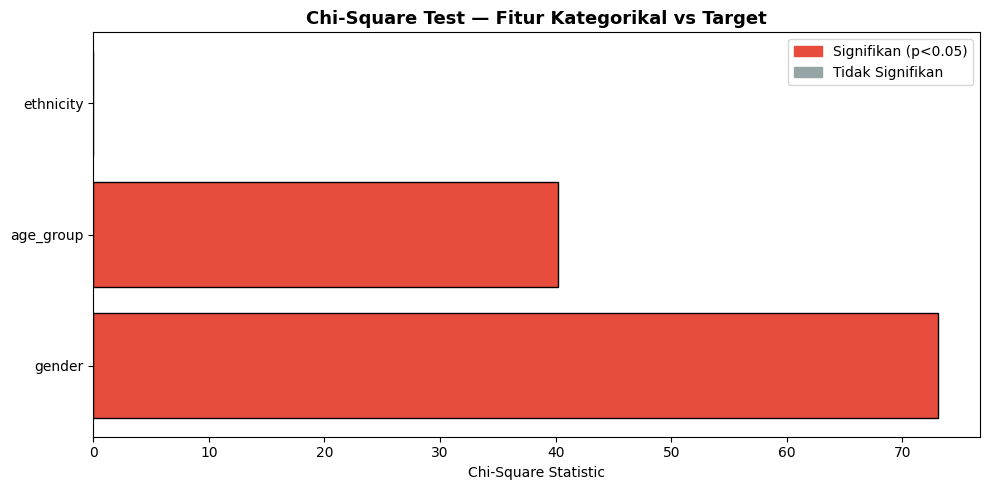

In [17]:
cat_cols = raw.select_dtypes(include=['object', 'category']).columns.tolist()
if label_col in cat_cols:
    cat_cols.remove(label_col)
print(f'Fitur kategorikal ({len(cat_cols)}): {cat_cols}')

chi2_results = []
for col in cat_cols:
    try:
        ct = pd.crosstab(raw[col], raw[label_col])
        chi2, p, dof, expected = stats.chi2_contingency(ct)
        chi2_results.append({'Feature': col, 'Chi2': round(chi2, 4),
                              'p-value': round(p, 6), 'DoF': dof,
                              'Significant (p<0.05)': '✅ Yes' if p < 0.05 else '❌ No'})
    except Exception as e:
        chi2_results.append({'Feature': col, 'Chi2': None, 'p-value': None,
                              'DoF': None, 'Significant (p<0.05)': f'Error: {e}'})

chi2_df = pd.DataFrame(chi2_results).sort_values('Chi2', ascending=False)
display(chi2_df)

# Visualisasi
chi2_valid = chi2_df.dropna(subset=['Chi2'])
if len(chi2_valid) > 0:
    fig, ax = plt.subplots(figsize=(10, max(5, len(chi2_valid)//2)))
    colors_chi = ['#e74c3c' if p < 0.05 else '#95a5a6'
                  for p in chi2_valid['p-value'].values]
    ax.barh(chi2_valid['Feature'], chi2_valid['Chi2'], color=colors_chi, edgecolor='black')
    ax.set_xlabel('Chi-Square Statistic')
    ax.set_title('Chi-Square Test — Fitur Kategorikal vs Target', fontsize=13, fontweight='bold')
    import matplotlib.patches as mpatches
    sig_patch = mpatches.Patch(color='#e74c3c', label='Signifikan (p<0.05)')
    ns_patch  = mpatches.Patch(color='#95a5a6', label='Tidak Signifikan')
    ax.legend(handles=[sig_patch, ns_patch])
    plt.tight_layout()
    plt.show()


# Data Preparation


## 1 · Concatenate Dataset (Image + Tabular)
Menggabungkan **dual-view image index** (AP + Lateral) dengan **data klinis tabular** berdasarkan `patient_id`.


### Clinical Data Loading & Validation
Standarisasi kolom, validasi tipe data, dan cleaning awal data klinis.


In [18]:
def clean_lumos_clinical(df: pd.DataFrame) -> pd.DataFrame:
    """Standardise clinical DataFrame dari LUMOS Excel."""
    df = df.copy()

    # Standardise patient_id
    id_col = next((c for c in df.columns if 'patient' in c or c == 'id'), None)
    if id_col and id_col != 'patient_id':
        df = df.rename(columns={id_col: 'patient_id'})
    df['patient_id'] = pd.to_numeric(df['patient_id'], errors='coerce').astype('Int64')

    # Standarisasi gender / sex
    for col in ['gender', 'sex']:
        if col in df.columns:
            df[col] = df[col].map(
                lambda x: str(x).strip().lower() if pd.notna(x) else np.nan
            )

    # Standarisasi label target
    if label_col in df.columns:
        df[label_col] = pd.to_numeric(df[label_col], errors='coerce')

    miss = df.isnull().mean().mul(100).round(1)
    miss = miss[miss > 0].sort_values(ascending=False)
    if not miss.empty:
        print(f'\nMissingness (%):\n{miss.to_string()}')
    return df.reset_index(drop=True)


clin_df = clean_lumos_clinical(raw)

# Distribusi kelas
dist = clin_df[label_col].value_counts().sort_index()
print('\nClass distribution:')
for k, v in dist.items():
    name = CLASS_NAMES[int(k)] if int(k) in range(3) else str(k)
    print(f'  {name:14} {int(v):4d}  {"█"*int(v/dist.max()*30)}')



Missingness (%):
t_l1_l2    0.1
t_l1_l3    0.1
t_l1_l4    0.1
t_l2_l3    0.1
t_l2_l4    0.1
t_l3_l4    0.1
z_l1_l2    0.1
z_l1_l3    0.1
z_l1_l4    0.1
z_l2_l3    0.1
z_l2_l4    0.1
z_l3_l4    0.1

Class distribution:
  normal          289  █████████████████████████████
  osteopenia      291  ██████████████████████████████
  osteoporosis    223  ██████████████████████


### Index-Safe Merge
Merge berdasarkan `patient_id` yang mempertahankan `global_idx` agar tidak terjadi *index drift*.


In [19]:
# ── Index-Safe Merge ──────────────────────────────────────────────────────
# img_df  : global_idx | patient_id | image_path_ap | image_path_lat
# clin_df : patient_id | age | gender | ... | osteoporosis

df_merged = img_df.merge(
    clin_df,
    on='patient_id',
    how='inner',  # hanya pasien yang memiliki KEDUANYA (gambar + klinis)
    validate='many_to_one'
)
# Pastikan index kontinu setelah merge
df_merged = df_merged.reset_index(drop=True)
# Simpan row_pos untuk verifikasi akhir
df_merged['row_pos'] = np.arange(len(df_merged))

print(f'Sebelum merge  : {len(img_df):,} gambar, {len(clin_df):,} klinis')
print(f'Setelah merge  : {len(df_merged):,} pasien valid (punya gambar + data klinis)')
print(f'Kolom df_merged: {list(df_merged.columns[:10])} ... ({len(df_merged.columns)} total)')
display(df_merged.head(3))


Sebelum merge  : 794 gambar, 803 klinis
Setelah merge  : 794 pasien valid (punya gambar + data klinis)
Kolom df_merged: ['global_idx', 'patient_id', 'image_path_ap', 'image_path_lat', 'age', 'gender', 'ethnicity', 'height', 'weight', 'bmi'] ... (57 total)


,global_idx,patient_id,image_path_ap,image_path_lat,age,gender,ethnicity,height,weight,bmi,...,avgh_l2_l4,avgh_l3_l4,avgw_l1_l2,avgw_l1_l3,avgw_l1_l4,avgw_l2_l3,avgw_l2_l4,avgw_l3_l4,age_group,row_pos
0,0,1,/kaggle/input/datasets/damarsyarafiramadhan/lu...,/kaggle/input/datasets/damarsyarafiramadhan/lu...,68,female,Asian,1.64,61.0,22.679952,...,9.83,6.59,3.90,3.90,4.02,3.78,3.98,4.14,60-69,0
1,1,2,/kaggle/input/datasets/damarsyarafiramadhan/lu...,/kaggle/input/datasets/damarsyarafiramadhan/lu...,30,female,Asian,1.56,45.0,18.491124,...,10.93,7.25,3.42,3.49,3.66,3.53,3.75,3.91,<50,1
2,2,3,/kaggle/input/datasets/damarsyarafiramadhan/lu...,/kaggle/input/datasets/damarsyarafiramadhan/lu...,59,female,Asian,1.59,66.0,26.106562,...,10.07,6.64,3.81,4.01,4.20,4.16,4.36,4.58,50-59,2


### Index Integrity Assertion
Validasi bahwa `global_idx` dan `row_pos` masih konsisten — tidak ada *drift*.


In [20]:
# ── Index Integrity Assertion ─────────────────────────────────────────────
assert df_merged['row_pos'].is_monotonic_increasing, \
    '❌ row_pos tidak monoton — ada index drift!'
assert df_merged['row_pos'].nunique() == len(df_merged), \
    '❌ row_pos duplikat — ada index drift!'
assert df_merged['patient_id'].nunique() == len(df_merged), \
    '❌ Ada patient_id duplikat setelah merge — periksa data!'

print('✅ Index integrity OK!')
print(f'   row_pos range  : {df_merged["row_pos"].min()} – {df_merged["row_pos"].max()}')
print(f'   global_idx OK  : {df_merged["global_idx"].is_monotonic_increasing}')
print(f'   Unique patients: {df_merged["patient_id"].nunique()}')


✅ Index integrity OK!
   row_pos range  : 0 – 793
   global_idx OK  : True
   Unique patients: 794


### Clean Categorical Values
Standarisasi nilai-nilai kategorikal: normalisasi case, hapus spasi berlebih, unify nilai yang tidak konsisten.


In [21]:
def clean_categorical_values(df: pd.DataFrame,
                              cat_columns: list) -> pd.DataFrame:
    """Standardise nilai kategorikal: lowercase, strip, replace inconsistencies."""
    df = df.copy()
    GENDER_MAP = {'female': 'Female', 'male': 'Male', 'f': 'Female', 'm': 'Male',
                  '0': 'Male', '1': 'Female', 0: 'Male', 1: 'Female'}
    for col in cat_columns:
        if col not in df.columns:
            continue
        # Strip whitespace
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({'nan': np.nan, 'None': np.nan, '': np.nan})
        # Gender standardisation
        if col in ('gender', 'sex'):
            df[col] = df[col].map(lambda x: GENDER_MAP.get(str(x).lower().strip(), x) if pd.notna(x) else x)
    return df

cat_cols_present = [c for c in CATEGORICAL_FEATURES if c in df_merged.columns]
df_merged = clean_categorical_values(df_merged, cat_cols_present)

print('Setelah cleaning kategorikal:')
for col in cat_cols_present:
    print(f'  {col}: {df_merged[col].value_counts().to_dict()}')


Setelah cleaning kategorikal:
  gender: {'Female': 639, 'Male': 155}


## 2 · Handling Missing Value & Duplicate
- **Missing Value**: Dilaporkan per kolom. Akan diimputasi oleh KNNImputer pada tahap preprocessing.
- **Duplikat**: Baris duplikat berdasarkan `patient_id` dihapus.


In [22]:
# ── Missing Values ────────────────────────────────────────────────────────
df_merged.isnull()
mv = df_merged.isnull().sum()
mv_pct = df_merged.isnull().mean().mul(100).round(2)
mv_report = pd.DataFrame({'Missing Count': mv, 'Missing %': mv_pct})
mv_report = mv_report[mv_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('Missing Values Report:')
display(mv_report)

# ── Duplikat ──────────────────────────────────────────────────────────────
n_dup = df_merged.duplicated(subset=['patient_id']).sum()
print(f'\nJumlah duplikat patient_id: {n_dup}')
if n_dup > 0:
    df_merged = df_merged.drop_duplicates(subset=['patient_id']).reset_index(drop=True)
    df_merged['row_pos'] = np.arange(len(df_merged))
    print(f'  → {n_dup} baris duplikat dihapus. Sisa: {len(df_merged)}')
else:
    print('  ✅ Tidak ada duplikat.')

# Hapus baris di mana target (label) kosong
before = len(df_merged)
df_merged = df_merged.dropna()
df_merged['row_pos'] = np.arange(len(df_merged))
print(f'\nBaris dengan target null dihapus: {before - len(df_merged)}')
print(f'Dataset setelah cleaning: {df_merged.shape}')


Missing Values Report:


,Missing Count,Missing %
t_l1_l2,1,0.13
t_l1_l3,1,0.13
t_l1_l4,1,0.13
t_l2_l3,1,0.13
t_l2_l4,1,0.13
t_l3_l4,1,0.13
z_l1_l2,1,0.13
z_l1_l3,1,0.13
z_l1_l4,1,0.13
z_l2_l3,1,0.13



Jumlah duplikat patient_id: 0
  ✅ Tidak ada duplikat.

Baris dengan target null dihapus: 1
Dataset setelah cleaning: (793, 57)


## 3 · Drop Useless Features
Hapus kolom yang:
1. Merupakan identifier saja (`patient_id`, `row_pos`, `global_idx`)
2. Path gambar (non-numerik)
3. Data leakage terhadap target
4. Variansi nol atau near-zero variance


In [23]:
# Kolom yang HARUS dipertahankan untuk pipeline
KEEP_ALWAYS = ['patient_id', 'global_idx', 'row_pos',
               'image_path_ap', 'image_path_lat', label_col]

# Near-zero variance: kolom numerik dengan std < 1e-6
num_cols_merged = df_merged.select_dtypes(include=[np.number]).columns.tolist()
nzv_cols = [c for c in num_cols_merged
            if c not in KEEP_ALWAYS and df_merged[c].std() < 1e-6]
print(f'Near-zero variance kolom: {nzv_cols}')

# Kolom yang dapat di-drop (non-fitur + NZV)
cols_to_drop = [c for c in EXCLUDED_COLS if c in df_merged.columns and c not in KEEP_ALWAYS]
cols_to_drop += nzv_cols
cols_to_drop = list(set(cols_to_drop))
print(f'Kolom yang di-drop: {cols_to_drop}')

df_clean = df_merged.drop(columns=cols_to_drop, errors='ignore')
print(f'Shape setelah drop: {df_clean.shape}')
print(f'Kolom tersisa: {list(df_clean.columns)}')

Near-zero variance kolom: []
Kolom yang di-drop: []
Shape setelah drop: (793, 57)
Kolom tersisa: ['global_idx', 'patient_id', 'image_path_ap', 'image_path_lat', 'age', 'gender', 'ethnicity', 'height', 'weight', 'bmi', 'osteoporosis', 'bmd', 'bmd_l1_l2', 'bmd_l1_l3', 'bmd_l1_l4', 'bmd_l2_l3', 'bmd_l2_l4', 'bmd_l3_l4', 'bmc_l1_l2', 'bmc_l1_l3', 'bmc_l1_l4', 'bmc_l2_l3', 'bmc_l2_l4', 'bmc_l3_l4', 's_l1_l2', 's_l1_l3', 's_l1_l4', 's_l2_l3', 's_l2_l4', 's_l3_l4', 't_value', 't_l1_l2', 't_l1_l3', 't_l1_l4', 't_l2_l3', 't_l2_l4', 't_l3_l4', 'z_l1_l2', 'z_l1_l3', 'z_l1_l4', 'z_l2_l3', 'z_l2_l4', 'z_l3_l4', 'avgh_l1_l2', 'avgh_l1_l3', 'avgh_l1_l4', 'avgh_l2_l3', 'avgh_l2_l4', 'avgh_l3_l4', 'avgw_l1_l2', 'avgw_l1_l3', 'avgw_l1_l4', 'avgw_l2_l3', 'avgw_l2_l4', 'avgw_l3_l4', 'age_group', 'row_pos']


### Mengecualikan Label Osteopenia

In [24]:
"""# ══════════════════════════════════════════════════════════════════════
#  DROP OSTEOPENIA — Reduksi 3-kelas → Binary (Normal vs Osteoporosis)
# ══════════════════════════════════════════════════════════════════════
print("="*65)
print("  SEBELUM: distribusi 3 kelas")
print("="*65)
dist_before = df_clean[label_col].value_counts().sort_index()
for k, v in dist_before.items():
    print(f"  {CLASS_NAMES[int(k)]:14} {int(v):4d}  {'█'*int(v/dist_before.max()*30)}")
n_before = len(df_clean)

# ── Filter: buang baris osteopenia (label == 1) ─────────────────────────
df_clean = df_clean[df_clean[label_col] != 1].copy()

# ── Remap label: normal(0)→0, osteoporosis(2)→1 (kontigu utk to_categorical) ──
df_clean[label_col] = df_clean[label_col].map({0: 0, 2: 1}).astype(int)
df_clean = df_clean.reset_index(drop=True)

# ── Update SEMUA konstanta global — cell downstream otomatis ikut ──────
N_CLASSES    = 2
LASS_NAMES  = ['normal', 'osteoporosis']
LABEL_MAP    = {'normal': 0, 'osteoporosis': 1}
CLASS_COLORS = {'#2ecc71': 'normal', '#e74c3c': 'osteoporosis'}

print(f"\n{'='*65}")
print(f"  SESUDAH: binary classification")
print(f"{'='*65}")
print(f"  Total pasien : {n_before} → {len(df_clean)}  "
      f"(−{n_before - len(df_clean)} osteopenia dibuang, "
      f"{(n_before-len(df_clean))/n_before:.1%} dari data)")

dist_after = df_clean[label_col].value_counts().sort_index()
for k, v in dist_after.items():
    print(f"  {CLASS_NAMES[int(k)]:14} {int(v):4d}  {'█'*int(v/dist_after.max()*30)}")

ratio = dist_after.max() / dist_after.min()
print(f"\n  Imbalance ratio baru : {ratio:.2f}x  "
      f"({'masih perlu class_weight' if ratio > 1.5 else 'relatif seimbang'})")
print(f"  N_CLASSES = {N_CLASSES}, CLASS_NAMES = {CLASS_NAMES}")"""

'# ══════════════════════════════════════════════════════════════════════\n#  DROP OSTEOPENIA — Reduksi 3-kelas → Binary (Normal vs Osteoporosis)\n# ══════════════════════════════════════════════════════════════════════\nprint("="*65)\nprint("  SEBELUM: distribusi 3 kelas")\nprint("="*65)\ndist_before = df_clean[label_col].value_counts().sort_index()\nfor k, v in dist_before.items():\n    print(f"  {CLASS_NAMES[int(k)]:14} {int(v):4d}  {\'█\'*int(v/dist_before.max()*30)}")\nn_before = len(df_clean)\n\n# ── Filter: buang baris osteopenia (label == 1) ─────────────────────────\ndf_clean = df_clean[df_clean[label_col] != 1].copy()\n\n# ── Remap label: normal(0)→0, osteoporosis(2)→1 (kontigu utk to_categorical) ──\ndf_clean[label_col] = df_clean[label_col].map({0: 0, 2: 1}).astype(int)\ndf_clean = df_clean.reset_index(drop=True)\n\n# ── Update SEMUA konstanta global — cell downstream otomatis ikut ──────\nN_CLASSES    = 2\nLASS_NAMES  = [\'normal\', \'osteoporosis\']\nLABEL_MAP    = {\'nor

## 5 · Split Stratified 80/10/10
Menggunakan Stratified K-Fold (K=5) agar proporsi kelas terjaga di setiap fold.
Split pada level patient untuk menghindari data leakage.

In [25]:
# ══════════════════════════════════════════════════════════════════════════
#  STRATIFIED SPLIT 80 / 10 / 10
# ══════════════════════════════════════════════════════════════════════════
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

label_col_raw = LABEL_COL
y_all = df_clean[label_col_raw].astype(int).values

# 80/10/10 split
idx_train, idx_temp = train_test_split(
    np.arange(len(df_clean)), test_size=0.20,
    stratify=y_all, random_state=RANDOM_STATE)

idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50,
    stratify=y_all[idx_temp], random_state=RANDOM_STATE)

df_train = df_clean.iloc[idx_train].reset_index(drop=True)
df_val   = df_clean.iloc[idx_val].reset_index(drop=True)
df_test  = df_clean.iloc[idx_test].reset_index(drop=True)

y_tr = df_train[label_col_raw].astype(int).values
y_va = df_val[label_col_raw].astype(int).values
y_te = df_test[label_col_raw].astype(int).values

print(f'Train: {len(df_train):,}  ({len(df_train)/len(df_clean)*100:.0f}%)')
print(f'Val  : {len(df_val):,}  ({len(df_val)/len(df_clean)*100:.0f}%)')
print(f'Test : {len(df_test):,}  ({len(df_test)/len(df_clean)*100:.0f}%)')

for name, y_s in [('Train', y_tr), ('Val', y_va), ('Test', y_te)]:
    dist = np.bincount(y_s, minlength=N_CLASSES)
    pct = dist / dist.sum() * 100
    print(f'\n{name}: ', end='')
    for c in range(N_CLASSES):
        print(f'{CLASS_NAMES[c]}={dist[c]}({pct[c]:.1f}%) ', end='')
print()

Train: 634  (80%)
Val  : 79  (10%)
Test : 80  (10%)

Train: normal=229(36.1%) osteopenia=228(36.0%) osteoporosis=177(27.9%) 
Val: normal=29(36.7%) osteopenia=28(35.4%) osteoporosis=22(27.8%) 
Test: normal=29(36.2%) osteopenia=29(36.2%) osteoporosis=22(27.5%) 


## 6 · Tabular Feature Preprocessing
Pipeline sklearn:
- **Numerik**: `KNNImputer(k=5)` → `StandardScaler()`
- **Kategorikal**: `SimpleImputer(most_frequent)` → `OneHotEncoder(handle_unknown='ignore')`


### Class Weight (Imbalance Class)
Compute class weights inversely proportional terhadap frekuensi kelas — digunakan pada loss function saat training.


Class weights (balanced):
  Class 0 (normal        ): 0.9229
  Class 1 (osteopenia    ): 0.9269
  Class 2 (osteoporosis  ): 1.1940


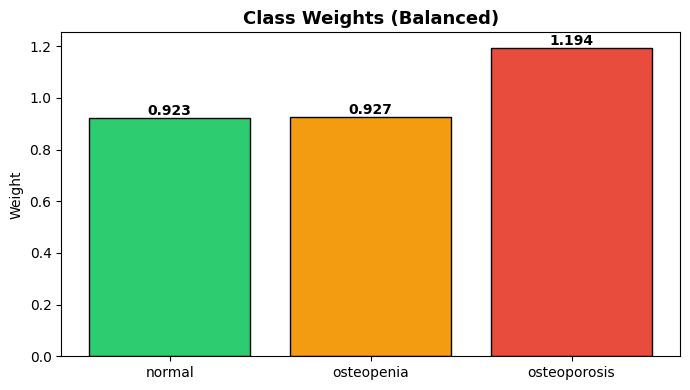

In [26]:
classes = np.unique(y_tr)
class_weights_arr = compute_class_weight('balanced', classes=classes, y=y_tr)
CLASS_WEIGHT_DICT = {int(c): float(w) for c, w in zip(classes, class_weights_arr)}

print('Class weights (balanced):')
for cls, w in CLASS_WEIGHT_DICT.items():
    name = CLASS_NAMES[cls] if cls in range(3) else str(cls)
    print(f'  Class {cls} ({name:14}): {w:.4f}')

# Visualisasi
fig, ax = plt.subplots(figsize=(7, 4))
names_cw = [CLASS_NAMES[k] if k in range(3) else str(k) for k in CLASS_WEIGHT_DICT.keys()]
ax.bar(names_cw, list(CLASS_WEIGHT_DICT.values()),
       color=['#2ecc71','#f39c12','#e74c3c'], edgecolor='black')
ax.set_title('Class Weights (Balanced)', fontsize=13, fontweight='bold')
ax.set_ylabel('Weight')
for i, (k, w) in enumerate(CLASS_WEIGHT_DICT.items()):
    ax.text(i, w + 0.01, f'{w:.3f}', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

# Modelling
## Arsitektur Dual-View Multimodal

```
AP Image ──────→ ResNet50 (frozen) → GAP → Dense 256 ─────┐
                                                            ├→ Concat 512 → Dense 256 ──→
Lateral Image ─→ ResNet50 (frozen) → GAP → Dense 256 ─────┘                            |
                                                                                         ├→ Attention Gate → Dense 128 → Softmax(3)
Tabular Data ──→ KNNImputer → StandardScaler/OHE → Dense 128 ────────────────────────→
```

**Two-Stage Fine-Tuning:**
- **Stage 1** (35 epochs): Hanya head yang dilatih, kedua ResNet50 dibekukan
- **Stage 2** (35 epochs): 20 layer terakhir tiap ResNet50 dibuka, lr dikurangi 100×


In [27]:
tf.keras.backend.clear_session()

### 3.1 · Load Prepared Data


In [28]:
# ── Custom Dual-View Data Generator ─────────────────────────────────────
class DualViewMultimodalGenerator(keras.utils.Sequence):
    def __init__(self, df, X_tab, y, batch_size=BATCH_SIZE,
                 img_size=IMG_SIZE, mode='npy', augment=False, shuffle=True):
        self.df         = df.reset_index(drop=True)
        self.X_tab      = X_tab
        self.y          = keras.utils.to_categorical(y, N_CLASSES)
        self.batch_size = batch_size
        self.img_size   = img_size
        self.mode       = mode
        self.augment    = augment
        self.shuffle    = shuffle
        self.indices    = np.arange(len(self.df))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size : (idx+1)*self.batch_size]
        bs = len(batch_idx)
        ap_batch  = np.zeros((bs,) + self.img_size + (3,), dtype=np.float32)
        lat_batch = np.zeros((bs,) + self.img_size + (3,), dtype=np.float32)
        tab_batch = self.X_tab[batch_idx]
        y_batch   = self.y[batch_idx]

        for i, bi in enumerate(batch_idx):
            row = self.df.iloc[bi]
            ap  = preprocess_image(row['image_path_ap'],  self.mode, self.img_size, view='ap')
            lat = preprocess_image(row['image_path_lat'], self.mode, self.img_size, view='lat')
            if self.augment:
                ap  = augment_image(ap)
                lat = augment_image(lat)
            ap_batch[i]  = ap
            lat_batch[i] = lat

        return ((ap_batch, lat_batch, tab_batch), y_batch)


def make_tf_dataset(generator):
    """Wrap ke tf.data.Dataset dengan explicit TensorSpec."""
    tab_dim = generator.X_tab.shape[1]
    img_shape = generator.img_size + (3,)
    output_signature = (
        (
            tf.TensorSpec(shape=(None,) + img_shape, dtype=tf.float32),
            tf.TensorSpec(shape=(None,) + img_shape, dtype=tf.float32),
            tf.TensorSpec(shape=(None, tab_dim), dtype=tf.float32),
        ),
        tf.TensorSpec(shape=(None, N_CLASSES), dtype=tf.float32),
    )
    def gen_func():
        for i in range(len(generator)):
            yield generator[i]
    return tf.data.Dataset.from_generator(gen_func, output_signature=output_signature).prefetch(tf.data.AUTOTUNE)


print('Generator ready ✓')

Generator ready ✓


In [29]:
# ══════════════════════════════════════════════════════════════════════════
#  GENERATORS — Per variant type
# ══════════════════════════════════════════════════════════════════════════

class ClinicalOnlyGenerator(keras.utils.Sequence):
    def __init__(self, X_tab, y, batch_size=BATCH_SIZE, shuffle=True):
        self.X_tab = X_tab
        self.y = keras.utils.to_categorical(y, N_CLASSES)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(X_tab))
        if shuffle: np.random.shuffle(self.indices)
    def __len__(self):
        return int(np.ceil(len(self.X_tab) / self.batch_size))
    def on_epoch_end(self):
        if self.shuffle: np.random.shuffle(self.indices)
    def __getitem__(self, idx):
        bi = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        return self.X_tab[bi], self.y[bi]


class ImageOnlyGenerator(keras.utils.Sequence):
    def __init__(self, df, y, batch_size=BATCH_SIZE, img_size=IMG_SIZE,
                 mode='npy', augment=False, shuffle=True):
        self.df = df.reset_index(drop=True)
        self.y = keras.utils.to_categorical(y, N_CLASSES)
        self.batch_size = batch_size
        self.img_size = img_size
        self.mode = mode
        self.augment = augment
        self.shuffle = shuffle
        self.indices = np.arange(len(self.df))
        if shuffle: np.random.shuffle(self.indices)
    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))
    def on_epoch_end(self):
        if self.shuffle: np.random.shuffle(self.indices)
    def __getitem__(self, idx):
        bi = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        bs = len(bi)
        ap_b  = np.zeros((bs,)+self.img_size+(3,), dtype=np.float32)
        lat_b = np.zeros((bs,)+self.img_size+(3,), dtype=np.float32)
        for i, b in enumerate(bi):
            row = self.df.iloc[b]
            ap  = preprocess_image(row['image_path_ap'],  self.mode, self.img_size, view='ap')
            lat = preprocess_image(row['image_path_lat'], self.mode, self.img_size, view='lat')
            if self.augment:
                ap = augment_image(ap); lat = augment_image(lat)
            ap_b[i] = ap; lat_b[i] = lat
        return (ap_b, lat_b), self.y[bi]


# DualViewMultimodalGenerator sudah ada dari cell sebelumnya (untuk C & D)
print('All generators ready ✓')

All generators ready ✓


In [30]:
# ══════════════════════════════════════════════════════════════════════════
#  ABLATION — 4 Model Builders
# ══════════════════════════════════════════════════════════════════════════

def build_clinical_only(tab_dim, n_classes=N_CLASSES, **kwargs):
    """A: Clinical-only MLP."""
    inp = layers.Input(shape=(tab_dim,), name='input_tab')
    x = layers.Dense(64, name='d1', activation='relu')(inp)
    x = layers.BatchNormalization(name='bn1')(x)
    #x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu', name='d2', kernel_regularizer=regularizers.l2(0.0001))(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Dropout(0.3)(x)
    #x = layers.Dense(64, activation='relu', name='d2')(x)
    #x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax', name='output')(x)
    return keras.Model(inputs=inp, outputs=out, name='Clinical_Only'), None, None


def _make_resnet_branch(input_shape, name_prefix, freeze=True):
    backbone = ResNet50(weights='imagenet', include_top=False,
                        input_shape=input_shape, name=f'resnet50_{name_prefix}')
    backbone.trainable = not freeze
    inp = layers.Input(shape=input_shape, name=f'input_{name_prefix}')
    x = backbone(inp, training=False)
    x = layers.GlobalAveragePooling2D(name=f'gap_{name_prefix}')(x)
    x = layers.BatchNormalization(name=f'bn_{name_prefix}')(x)
    x = layers.Dense(256, activation='relu', name=f'dense_{name_prefix}')(x)
    x = layers.Dropout(0.3, name=f'drop_{name_prefix}')(x)
    return inp, x, backbone


def build_image_only(tab_dim, n_classes=N_CLASSES, img_size=IMG_SIZE, freeze=True):
    """B: Image-only Dual ResNet50."""
    input_shape = img_size + (3,)
    inp_ap,  feat_ap,  bb_ap  = _make_resnet_branch(input_shape, 'ap', freeze)
    inp_lat, feat_lat, bb_lat = _make_resnet_branch(input_shape, 'lat', freeze)
    x = layers.Concatenate(name='img_concat')([feat_ap, feat_lat])
    x = layers.Dense(256, activation='relu', name='img_fused')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu', name='img_d2', kernel_regularizer=regularizers.l2(0.0001))(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax', name='output')(x)
    return keras.Model(inputs=[inp_ap, inp_lat], outputs=out, name='Image_Only'), bb_ap, bb_lat


def _make_tab_branch(tab_dim):
    inp = layers.Input(shape=(tab_dim,), name='input_tab')
    t = layers.Dense(64, name='tab_d1')(inp)
    t = layers.BatchNormalization(name='tab_bn1')(t)
    t = layers.Activation('relu')(t)
    t = layers.Dense(32, activation='relu', name='d2', kernel_regularizer=regularizers.l2(0.0001))(x)
    t = layers.BatchNormalization(name='bn2')(x)
    t = layers.Dropout(0.3)(x)
    #t = layers.Dropout(0.3, name='tab_drop1')(t)
    #t = layers.Dense(128, activation='relu', name='tab_d2')(t)
    return inp, t


def build_multimodal_no_gating(tab_dim, n_classes=N_CLASSES, img_size=IMG_SIZE, freeze=True):
    """C: Multimodal — simple concat (tanpa gating)."""
    input_shape = img_size + (3,)
    inp_ap,  feat_ap,  bb_ap  = _make_resnet_branch(input_shape, 'ap', freeze)
    inp_lat, feat_lat, bb_lat = _make_resnet_branch(input_shape, 'lat', freeze)
    img = layers.Concatenate(name='img_concat')([feat_ap, feat_lat])
    img = layers.Dense(256, activation='relu', name='img_fused')(img)
    img = layers.Dropout(0.3, name='drop_img')(img)
    inp_tab, t = _make_tab_branch(tab_dim)
    fusion = layers.Concatenate(name='mm_concat')([img, t])
    x = layers.Dense(128, activation='relu', name='fusion_d', kernel_regularizer=regularizers.l2(0.0001))(fusion)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax', name='output')(x)
    return keras.Model(inputs=[inp_ap, inp_lat, inp_tab], outputs=out,
                       name='Multimodal_NoGating'), bb_ap, bb_lat


def build_multimodal_gating(tab_dim, n_classes=N_CLASSES, img_size=IMG_SIZE, freeze=True):
    """D: Multimodal — sigmoid attention gating."""
    input_shape = img_size + (3,)
    inp_ap,  feat_ap,  bb_ap  = _make_resnet_branch(input_shape, 'ap', freeze)
    inp_lat, feat_lat, bb_lat = _make_resnet_branch(input_shape, 'lat', freeze)
    img = layers.Concatenate(name='img_concat')([feat_ap, feat_lat])
    img = layers.Dense(256, activation='relu', name='img_fused')(img)
    img = layers.Dropout(0.3, name='drop_img')(img)
    inp_tab, t = _make_tab_branch(tab_dim)
    fusion = layers.Concatenate(name='mm_concat')([img, t])
    att = layers.Dense(320, activation='sigmoid', name='attention_gate', kernel_regularizer=regularizers.l2(0.0001))(fusion)
    fusion = layers.Multiply(name='att_applied')([fusion, att])
    x = layers.Dense(128, activation='relu', name='fusion_d', kernel_regularizer=regularizers.l2(0.0001))(fusion)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax', name='output')(x)
    return keras.Model(inputs=[inp_ap, inp_lat, inp_tab], outputs=out,
                       name='Multimodal_Gating'), bb_ap, bb_lat


ABLATION_VARIANTS = {
    'A_Clinical_Only':       {'builder': build_clinical_only,       'img': False, 'tab': True,  'gate': False},
    'B_Image_Only':          {'builder': build_image_only,          'img': True,  'tab': False, 'gate': False},
    'C_Multimodal_NoGating': {'builder': build_multimodal_no_gating,'img': True,  'tab': True,  'gate': False},
    'D_Multimodal_Gating':   {'builder': build_multimodal_gating,   'img': True,  'tab': True,  'gate': True},
}

print('4 ablation model builders ready ✓')

4 ablation model builders ready ✓


In [31]:
def model_parameter_summary(model):
    trainable = np.sum([
        np.prod(v.shape) for v in model.trainable_weights
    ])

    non_trainable = np.sum([
        np.prod(v.shape) for v in model.non_trainable_weights
    ])

    return {
        "model": model.name,
        "total_params": int(model.count_params()),
        "trainable_params": int(trainable),
        "non_trainable_params": int(non_trainable),
    }


parameter_results = []

for variant_name, variant_info in ABLATION_VARIANTS.items():
    keras.backend.clear_session()

    model, bb_ap, bb_lat = variant_info["builder"](
        tab_dim=6,
        n_classes=3
    )

    parameter_results.append(
        model_parameter_summary(model)
    )

parameter_df = pd.DataFrame(parameter_results)
display(parameter_df)

I0000 00:00:1785657375.931968      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


,model,total_params,trainable_params,non_trainable_params
0,Clinical_Only,5059,4931,128
1,Image_Only,48405507,1221891,47183616
2,Multimodal_NoGating,48393667,1209923,47183744
3,Multimodal_Gating,48517123,1333379,47183744


# Modelling

In [32]:
def get_callbacks(fold_idx):
    ckpt = str(MODEL_DIR / f'best_fold{fold_idx}.keras')
    return [
        ModelCheckpoint(ckpt, monitor='val_accuracy', save_best_only=True, mode='max', verbose=0),
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-7, verbose=0),
    ]

### 3.4 · Training Model


In [33]:
# ══════════════════════════════════════════════════════════════════════════
#  TABULAR PREPROCESSING + CLASS WEIGHTS + GENERATORS
# ══════════════════════════════════════════════════════════════════════════
feat_cols      = [c for c in df_clean.columns if c not in KEEP_ALWAYS + [label_col_raw, 'row_pos']]
num_feat_avail = [c for c in NUM_FEATURES         if c in feat_cols]
cat_feat_avail = [c for c in CATEGORICAL_FEATURES if c in feat_cols]
print(f'Fitur numerik   : {num_feat_avail}')
print(f'Fitur kategorikal: {cat_feat_avail}')

num_pipe = Pipeline([('scl', StandardScaler())])
cat_pipe = Pipeline([('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_feat_avail),
    ('cat', cat_pipe, cat_feat_avail)
], remainder='drop')

def ext_tab(df):
    return df[[c for c in num_feat_avail + cat_feat_avail if c in df.columns]].copy()

preprocessor.fit(ext_tab(df_train))
X_tab_tr = preprocessor.transform(ext_tab(df_train)).astype(np.float32)
X_tab_va = preprocessor.transform(ext_tab(df_val)).astype(np.float32)
X_tab_te = preprocessor.transform(ext_tab(df_test)).astype(np.float32)
tab_dim  = X_tab_tr.shape[1]
print(f'Tab dim: {tab_dim}  (num={len(num_feat_avail)}, ohe={tab_dim - len(num_feat_avail)})')

# Class weights
cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
CLASS_WEIGHT_DICT = {int(c): float(w) for c, w in zip(np.unique(y_tr), cw)}
print(f'Class weights: {CLASS_WEIGHT_DICT}')

Fitur numerik   : ['age', 'height', 'weight', 'bmi']
Fitur kategorikal: ['gender']
Tab dim: 6  (num=4, ohe=2)
Class weights: {0: 0.9228529839883551, 1: 0.9269005847953217, 2: 1.1939736346516008}


In [34]:
# ══════════════════════════════════════════════════════════════════════════
#  TAMPILKAN HASIL PIPELINE PER FITUR (Standalone Demo)
# ══════════════════════════════════════════════════════════════════════════

# ── Buat preprocessor demo dari df_clean ─────────────────────────────────
_num_pipe = Pipeline([('imp', KNNImputer(n_neighbors=5)), ('scl', StandardScaler())])
_cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
_demo_prep = ColumnTransformer([
    ('num', _num_pipe, num_feat_avail),
    ('cat', _cat_pipe, cat_feat_avail)
], remainder='drop')

_demo_df = df_clean[[c for c in num_feat_avail + cat_feat_avail if c in df_clean.columns]].copy()
_X_demo = _demo_prep.fit_transform(_demo_df).astype(np.float32)

# ── 1. Nama kolom output ────────────────────────────────────────────────
feature_names_out = _demo_prep.get_feature_names_out()
print(f'Total fitur output: {len(feature_names_out)}')
print(f'Nama kolom: {list(feature_names_out)}\n')

# ── 2. Sebelum vs Sesudah ───────────────────────────────────────────────
n_show = min(10, len(df_clean))
raw_cols = num_feat_avail + cat_feat_avail
df_before = df_clean[raw_cols].head(n_show).copy()
df_before.insert(0, 'patient_id', df_clean['patient_id'].head(n_show).values)

df_after = pd.DataFrame(_X_demo[:n_show], columns=feature_names_out).round(4)
df_after.insert(0, 'patient_id', df_clean['patient_id'].head(n_show).values)

print('═' * 80)
print('SEBELUM PREPROCESSING (raw):')
print('═' * 80)
display(df_before)

print('\n')
print('═' * 80)
print('SESUDAH PREPROCESSING (StandardScaler + OHE):')
print('═' * 80)
display(df_after)

# ── 3. Detail StandardScaler ─────────────────────────────────────────────
print('\n')
print('═' * 80)
print('DETAIL STANDARDSCALER — μ (mean) dan σ (std) per fitur numerik:')
print('═' * 80)

scaler = _demo_prep.named_transformers_['num'].named_steps['scl']
scaler_df = pd.DataFrame({
    'Fitur': num_feat_avail,
    'Mean (μ)': scaler.mean_,
    'Std (σ)': scaler.scale_,
}).round(4)
display(scaler_df)

print('\nRumus: z = (x - μ) / σ')
print('Contoh:')
for i, feat in enumerate(num_feat_avail):
    raw_val = df_clean[feat].iloc[0]
    mu = scaler.mean_[i]
    sigma = scaler.scale_[i]
    z = (raw_val - mu) / sigma
    print(f'  {feat:8}: x={raw_val:.2f} → z=({raw_val:.2f} - {mu:.2f}) / {sigma:.2f} = {z:.4f}')

# ── 4. Detail OHE ────────────────────────────────────────────────────────
print('\n')
print('═' * 80)
print('DETAIL ONE-HOT ENCODING — Kategori per fitur:')
print('═' * 80)

ohe = _demo_prep.named_transformers_['cat'].named_steps['ohe']
for i, feat in enumerate(cat_feat_avail):
    cats = list(ohe.categories_[i])
    print(f'\n  {feat}:')
    print(f'    Kategori terdeteksi: {cats}')
    print(f'    Jumlah kolom OHE  : {len(cats)}')
    print(f'    Mapping:')
    for cat in cats:
        vec = [0] * len(cats)
        vec[cats.index(cat)] = 1
        print(f'      "{cat}" → {vec}')

# ── 5. Side-by-side 3 pasien ─────────────────────────────────────────────
print('\n')
print('═' * 80)
print('SIDE-BY-SIDE — 3 pasien pertama:')
print('═' * 80)

for idx in range(min(3, len(df_clean))):
    pid = df_clean['patient_id'].iloc[idx]
    print(f'\n  Patient {pid}:')
    print(f'  {"─"*60}')
    print(f'  SEBELUM (raw):')
    for feat in num_feat_avail:
        print(f'    {feat:10}: {df_clean[feat].iloc[idx]}')
    for feat in cat_feat_avail:
        print(f'    {feat:10}: {df_clean[feat].iloc[idx]}')
    print(f'  SESUDAH (transformed):')
    for j, col_name in enumerate(feature_names_out):
        val = _X_demo[idx, j]
        if 'num__' in col_name:
            src = col_name.replace('num__', '')
            raw = df_clean[src].iloc[idx]
            print(f'    {col_name:30}: {raw:>8} → {val:>8.4f}  (standardized)')
        elif 'cat__' in col_name:
            print(f'    {col_name:30}:          → {val:>8.0f}  (one-hot)')

# Cleanup demo variables
del _num_pipe, _cat_pipe, _demo_prep, _demo_df, _X_demo
print('\n✅ Demo selesai (variabel demo sudah di-cleanup)')

Total fitur output: 6
Nama kolom: ['num__age', 'num__height', 'num__weight', 'num__bmi', 'cat__gender_Female', 'cat__gender_Male']

════════════════════════════════════════════════════════════════════════════════
SEBELUM PREPROCESSING (raw):
════════════════════════════════════════════════════════════════════════════════


,patient_id,age,height,weight,bmi,gender
0,1,68,1.640,61.0,22.679952,Female
1,2,30,1.560,45.0,18.491124,Female
2,3,59,1.590,66.0,26.106562,Female
3,4,58,1.590,54.0,21.359915,Female
4,5,80,1.650,67.5,24.793388,Male
5,6,73,1.550,42.0,17.481790,Female
6,7,55,1.620,71.0,27.053803,Male
7,8,30,1.580,47.0,18.827111,Female
8,9,83,1.750,65.0,21.224490,Male
9,10,64,1.545,66.0,27.649480,Female




════════════════════════════════════════════════════════════════════════════════
SESUDAH PREPROCESSING (StandardScaler + OHE):
════════════════════════════════════════════════════════════════════════════════


,patient_id,num__age,num__height,num__weight,num__bmi,cat__gender_Female,cat__gender_Male
0,1,0.3302,0.8018,0.2102,-0.2085,1.0,0.0
1,2,-2.7631,-0.2783,-1.2684,-1.3192,1.0,0.0
2,3,-0.4024,0.1268,0.6723,0.7001,1.0,0.0
3,4,-0.4838,0.1268,-0.4367,-0.5585,1.0,0.0
4,5,1.3071,0.9368,0.8109,0.3519,0.0,1.0
5,6,0.7372,-0.4133,-1.5456,-1.5868,1.0,0.0
6,7,-0.7280,0.5318,1.1344,0.9512,0.0,1.0
7,8,-2.7631,-0.0083,-1.0836,-1.2301,1.0,0.0
8,9,1.5513,2.2870,0.5799,-0.5944,0.0,1.0
9,10,0.0046,-0.4808,0.6723,1.1092,1.0,0.0




════════════════════════════════════════════════════════════════════════════════
DETAIL STANDARDSCALER — μ (mean) dan σ (std) per fitur numerik:
════════════════════════════════════════════════════════════════════════════════


,Fitur,Mean (μ),Std (σ)
0,age,63.9433,12.2847
1,height,1.5806,0.0741
2,weight,58.7251,10.8208
3,bmi,23.4664,3.7714



Rumus: z = (x - μ) / σ
Contoh:
  age     : x=68.00 → z=(68.00 - 63.94) / 12.28 = 0.3302
  height  : x=1.64 → z=(1.64 - 1.58) / 0.07 = 0.8018
  weight  : x=61.00 → z=(61.00 - 58.73) / 10.82 = 0.2102
  bmi     : x=22.68 → z=(22.68 - 23.47) / 3.77 = -0.2085


════════════════════════════════════════════════════════════════════════════════
DETAIL ONE-HOT ENCODING — Kategori per fitur:
════════════════════════════════════════════════════════════════════════════════

  gender:
    Kategori terdeteksi: ['Female', 'Male']
    Jumlah kolom OHE  : 2
    Mapping:
      "Female" → [1, 0]
      "Male" → [0, 1]


════════════════════════════════════════════════════════════════════════════════
SIDE-BY-SIDE — 3 pasien pertama:
════════════════════════════════════════════════════════════════════════════════

  Patient 1:
  ────────────────────────────────────────────────────────────
  SEBELUM (raw):
    age       : 68
    height    : 1.64
    weight    : 61.0
    bmi       : 22.6799524092802
    gende

In [35]:
# ══════════════════════════════════════════════════════════════════════════
#  ABLATION STUDY — 4 Variants × Single Split (80/10/10)
# ══════════════════════════════════════════════════════════════════════════
ablation_results = {}

for vname, vinfo in ABLATION_VARIANTS.items():
    print(f'\n{"═"*70}')
    print(f'  {vname}  (img={vinfo["img"]}, tab={vinfo["tab"]}, gate={vinfo["gate"]})')
    print(f'{"═"*70}')

    keras.backend.clear_session(); gc.collect()

    # ── Generators ────────────────────────────────────────────────────────
    if not vinfo['img'] and vinfo['tab']:
        tr_gen = ClinicalOnlyGenerator(X_tab_tr, y_tr, shuffle=True)
        va_gen = ClinicalOnlyGenerator(X_tab_va, y_va, shuffle=False)
        te_gen = ClinicalOnlyGenerator(X_tab_te, y_te, shuffle=False)
    elif vinfo['img'] and not vinfo['tab']:
        tr_gen = ImageOnlyGenerator(df_train, y_tr, augment=True,  shuffle=True,  mode=IMAGE_MODE)
        va_gen = ImageOnlyGenerator(df_val, y_va,   augment=False, shuffle=False, mode=IMAGE_MODE)
        te_gen = ImageOnlyGenerator(df_test, y_te,  augment=False, shuffle=False, mode=IMAGE_MODE)
    else:
        tr_gen = DualViewMultimodalGenerator(df_train, X_tab_tr, y_tr, augment=True,  shuffle=True,  mode=IMAGE_MODE)
        va_gen = DualViewMultimodalGenerator(df_val, X_tab_va, y_va,   augment=False, shuffle=False, mode=IMAGE_MODE)
        te_gen = DualViewMultimodalGenerator(df_test, X_tab_te, y_te,  augment=False, shuffle=False, mode=IMAGE_MODE)

    # ── Build ─────────────────────────────────────────────────────────────
    model, bb_ap, bb_lat = vinfo['builder'](tab_dim)

    ckpt = str(MODEL_DIR / f'best_{vname}.keras')
    cbs = [
        ModelCheckpoint(ckpt, monitor='val_accuracy', save_best_only=True, mode='max', verbose=0),
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-7, verbose=0),
    ]

    # ── Train ─────────────────────────────────────────────────────────────
    hist1 = hist2 = None
    if bb_ap is not None:
        model.compile(optimizer=keras.optimizers.Adam(HEAD_LR),
                      loss='categorical_crossentropy', metrics=['accuracy'])
        print(f'  Stage 1: Head ({EPOCHS_STAGE1} ep)')
        hist1 = model.fit(tr_gen, validation_data=va_gen, epochs=EPOCHS_STAGE1,
                          callbacks=cbs, class_weight=CLASS_WEIGHT_DICT, verbose=1)

        for bb in [bb_ap, bb_lat]:
            bb.trainable = True
            for layer in bb.layers[:-FINE_TUNE_LAYERS]:
                layer.trainable = False
        model.compile(optimizer=keras.optimizers.Adam(FINE_TUNE_LR),
                      loss='categorical_crossentropy', metrics=['accuracy'])
        print(f'  Stage 2: Fine-tune ({EPOCHS_STAGE2} ep)')
        hist2 = model.fit(tr_gen, validation_data=va_gen, epochs=EPOCHS_STAGE2,
                          callbacks=cbs, class_weight=CLASS_WEIGHT_DICT, verbose=1)
    else:
        model.compile(optimizer=keras.optimizers.Adam(HEAD_LR),
                      loss='categorical_crossentropy', metrics=['accuracy'])
        print(f'  Training 1-stage ({EPOCHS} ep)')
        hist1 = model.fit(tr_gen, validation_data=va_gen, epochs=EPOCHS,
                          callbacks=cbs, class_weight=CLASS_WEIGHT_DICT, verbose=1)

    # ── Evaluate ──────────────────────────────────────────────────────────
    y_prob = model.predict(te_gen, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_te, y_pred, average='macro', zero_division=0)
    try:
        y_bin = label_binarize(y_te, classes=list(range(N_CLASSES)))
        auc_v = roc_auc_score(y_bin, y_prob, average='macro', multi_class='ovr')
    except:
        auc_v = 0.0

    ablation_results[vname] = {
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'f1': f1, 'auc': auc_v,
        'cm': confusion_matrix(y_te, y_pred),
        'y_true': y_te.copy(),
        'y_pred': y_pred.copy(),
        'y_pred_prob': y_prob.copy(),
        'history_stage1': hist1.history if hist1 is not None else {},
        'history_stage2': hist2.history if hist2 is not None else {},
        'model_name': vname,
    }

    print(f'\n  ✅ Acc={acc:.4f} Prec={prec:.4f} Rec={rec:.4f} F1={f1:.4f} AUC={auc_v:.4f}')

    # Simpan model terbaik (jangan delete)
    del tr_gen, va_gen, te_gen
    keras.backend.clear_session(); gc.collect()

print('\n' + '═'*70)
print('✅ ABLATION COMPLETE')
print('═'*70)


══════════════════════════════════════════════════════════════════════
  A_Clinical_Only  (img=False, tab=True, gate=False)
══════════════════════════════════════════════════════════════════════
  Training 1-stage (70 ep)
Epoch 1/70
 1/40 ━━━━━━━━━━━━━━━━━━━━ 1:30 2s/step - accuracy: 0.5625 - loss: 0.8856

I0000 00:00:1785657389.206961     139 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.4369 - loss: 1.0843 - val_accuracy: 0.3418 - val_loss: 1.0669 - learning_rate: 0.0010
Epoch 2/70
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5047 - loss: 1.0045 - val_accuracy: 0.3924 - val_loss: 1.0319 - learning_rate: 0.0010
Epoch 3/70
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5189 - loss: 0.9941 - val_accuracy: 0.3924 - val_loss: 1.0299 - learning_rate: 0.0010
Epoch 4/70
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4953 - loss: 0.9979 - val_accuracy: 0.4177 - val_loss: 1.0295 - learning_rate: 0.0010
Epoch 5/70
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5032 - loss: 0.9977 - val_accuracy: 0.3671 - val_loss: 1.0260 - learning_rate: 0.0010
Epoch 6/70
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5205 - loss: 0.9935 - val_accuracy: 0.4051 - val_loss: 1.0494 - learning_rate: 0.0010
Epoch 7/70
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5000 - loss: 0.9985 - val_accuracy: 0.3797 - v

### 3.6 · Plot Training Curves


ABLATION RESULTS (80/10/10 Split):


,Variant,Accuracy,Precision,Recall,F1-Score,AUC
0,A · Clinical Only,0.5125,0.5006,0.5298,0.5100,0.7226
1,B · Image Only,0.4750,0.4705,0.4660,0.4452,0.6320
2,C · Multimodal (no gate),0.5375,0.5190,0.5601,0.5055,0.7478
3,D · Multimodal (gate) ★,0.5250,0.5211,0.5522,0.4602,0.7697



🏆 Best (F1): A · Clinical Only → F1=0.5100


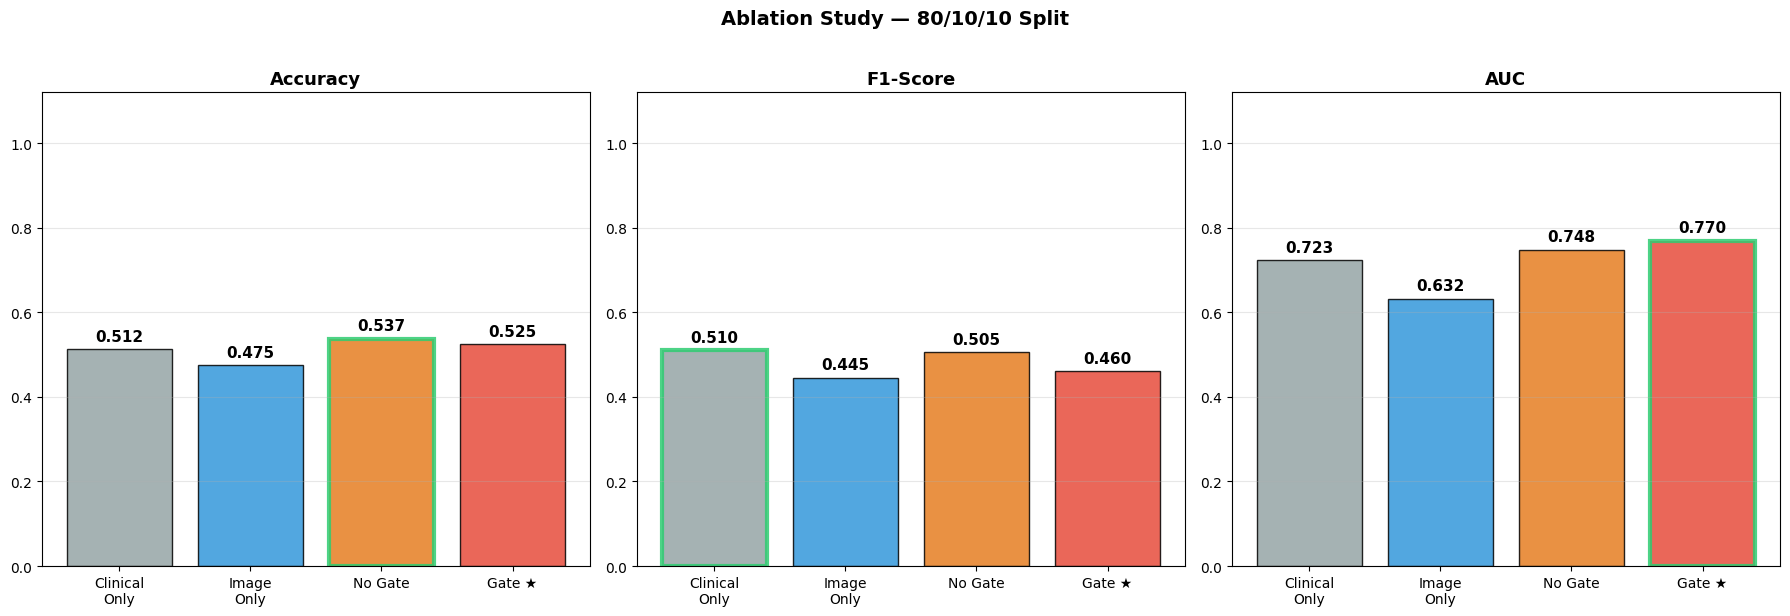

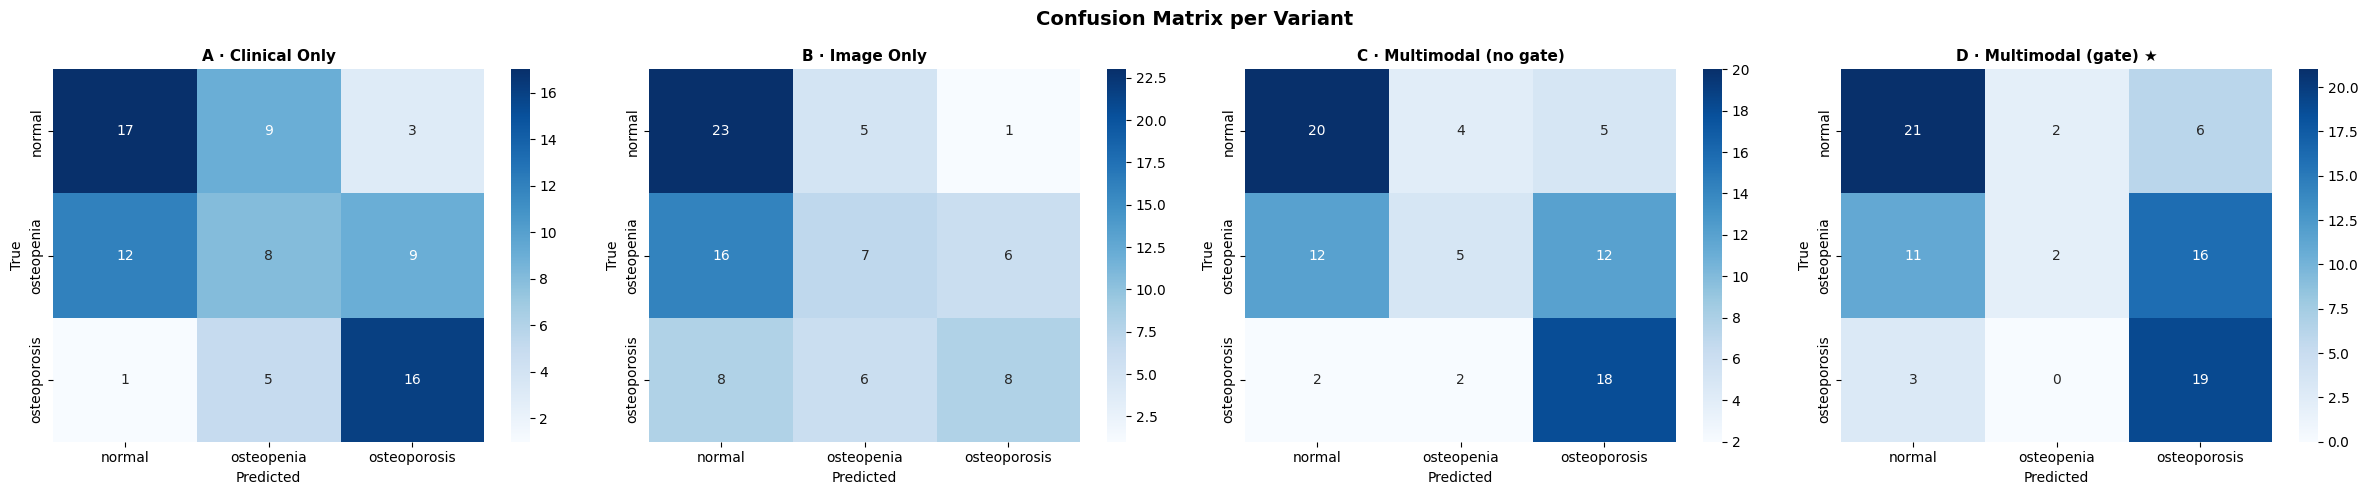


DELTA vs Clinical-Only Baseline:
──────────────────────────────────────────────────────────────────────
  B · Image Only                      ΔAcc=-0.0375  ΔF1=-0.0648  ΔAUC=-0.0906
  C · Multimodal (no gate)            ΔAcc=+0.0250  ΔF1=-0.0045  ΔAUC=+0.0253
  D · Multimodal (gate) ★             ΔAcc=+0.0125  ΔF1=-0.0498  ΔAUC=+0.0471

GATING EFFECT (D vs C):
──────────────────────────────────────────────────────────────────────
  Accuracy  : NoGate=0.5375  Gate=0.5250  Δ=-0.0125
  F1        : NoGate=0.5055  Gate=0.4602  Δ=-0.0453
  AUC       : NoGate=0.7478  Gate=0.7697  Δ=+0.0218

✅ Saved to /kaggle/working/model_lumos_dual


In [36]:
# ══════════════════════════════════════════════════════════════════════════
#  ABLATION RESULTS — Single Split
# ══════════════════════════════════════════════════════════════════════════
VLABELS = {
    'A_Clinical_Only':       'A · Clinical Only',
    'B_Image_Only':          'B · Image Only',
    'C_Multimodal_NoGating': 'C · Multimodal (no gate)',
    'D_Multimodal_Gating':   'D · Multimodal (gate) ★',
}
VCOLORS = ['#95a5a6', '#3498db', '#e67e22', '#e74c3c']
SHORT_LABELS = ['Clinical\nOnly', 'Image\nOnly', 'No Gate', 'Gate ★']

rows = []
for vname, m in ablation_results.items():
    rows.append({
        'Variant': VLABELS.get(vname, vname),
        'Accuracy': m['accuracy'], 'Precision': m['precision'],
        'Recall': m['recall'], 'F1-Score': m['f1'], 'AUC': m['auc'],
    })
results_df = pd.DataFrame(rows)

print('ABLATION RESULTS (80/10/10 Split):')
print('='*80)
display(results_df.round(4))

best_idx = results_df['F1-Score'].idxmax()
best_vname = list(ablation_results.keys())[best_idx]
print(f'\n🏆 Best (F1): {VLABELS[best_vname]} → F1={results_df.iloc[best_idx]["F1-Score"]:.4f}')

# ── Bar Chart ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Ablation Study — 80/10/10 Split', fontsize=14, fontweight='bold', y=1.02)

for ax_i, met in enumerate(['Accuracy', 'F1-Score', 'AUC']):
    ax = axes[ax_i]
    vals = results_df[met].values
    bars = ax.bar(SHORT_LABELS, vals, color=VCOLORS, edgecolor='black', alpha=0.85)
    ax.set_title(met, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.12); ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f'{v:.3f}', ha='center', fontweight='bold', fontsize=11)
    best_i = int(np.argmax(vals))
    bars[best_i].set_edgecolor('#2ecc71'); bars[best_i].set_linewidth(3)

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'ablation_bars.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Confusion Matrices ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle('Confusion Matrix per Variant', fontsize=14, fontweight='bold')

for ax_i, (vname, m) in enumerate(ablation_results.items()):
    ax = axes[ax_i]
    sns.heatmap(m['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(VLABELS[vname], fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'ablation_cm.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Delta Analysis ───────────────────────────────────────────────────────
print('\nDELTA vs Clinical-Only Baseline:')
print('─'*70)
base = ablation_results['A_Clinical_Only']
for vname, m in ablation_results.items():
    if vname == 'A_Clinical_Only': continue
    da = m['accuracy'] - base['accuracy']
    df1 = m['f1'] - base['f1']
    dau = m['auc'] - base['auc']
    print(f'  {VLABELS[vname]:35} ΔAcc={"+" if da>=0 else ""}{da:.4f}  '
          f'ΔF1={"+" if df1>=0 else ""}{df1:.4f}  ΔAUC={"+" if dau>=0 else ""}{dau:.4f}')

print('\nGATING EFFECT (D vs C):')
print('─'*70)
c = ablation_results['C_Multimodal_NoGating']
d = ablation_results['D_Multimodal_Gating']
for met, key in [('Accuracy','accuracy'), ('F1','f1'), ('AUC','auc')]:
    delta = d[key] - c[key]
    print(f'  {met:10}: NoGate={c[key]:.4f}  Gate={d[key]:.4f}  Δ={"+" if delta>=0 else ""}{delta:.4f}')

# ── Save ──────────────────────────────────────────────────────────────────
results_df.to_csv(str(MODEL_DIR / 'ablation_results.csv'), index=False)
print(f'\n✅ Saved to {MODEL_DIR}')

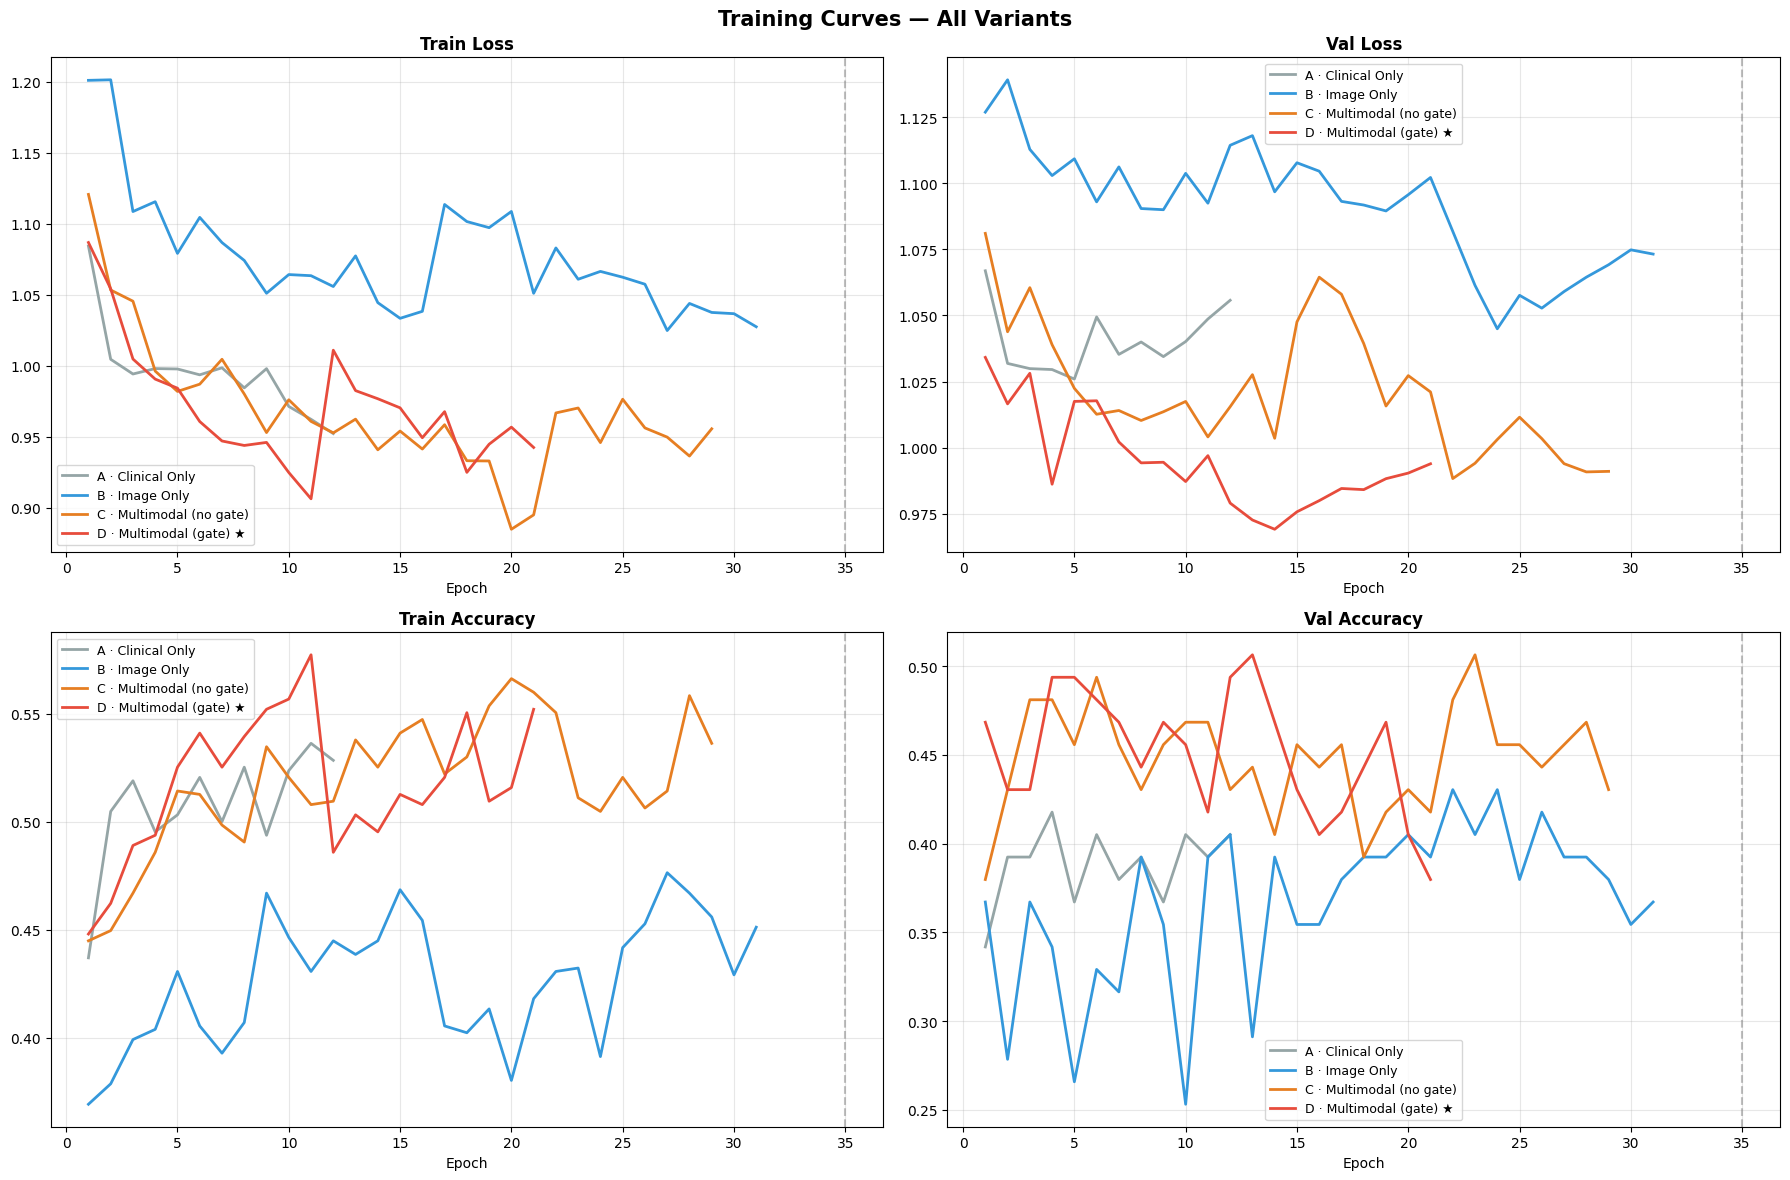

In [37]:
# ── Line Plot Training Curves ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Training Curves — All Variants', fontsize=15, fontweight='bold')

VCOLORS_LINE = {
    'A_Clinical_Only': '#95a5a6', 'B_Image_Only': '#3498db',
    'C_Multimodal_NoGating': '#e67e22', 'D_Multimodal_Gating': '#e74c3c',
}

for row_idx, (tr_key, va_key, tr_title, va_title) in enumerate([
    ('loss', 'val_loss', 'Train Loss', 'Val Loss'),
    ('accuracy', 'val_accuracy', 'Train Accuracy', 'Val Accuracy')]):

    ax_tr = axes[row_idx, 0]
    ax_va = axes[row_idx, 1]

    for vname, m in ablation_results.items():
        h1 = m.get('history_stage1', {})
        h2 = m.get('history_stage2', {})
        train_v = h1.get(tr_key, []) + h2.get(tr_key, [])
        val_v   = h1.get(va_key, []) + h2.get(va_key, [])
        if not train_v:
            continue
        epochs = range(1, len(train_v) + 1)
        color = VCOLORS_LINE[vname]
        label = VLABELS[vname]
        ax_tr.plot(epochs, train_v, color=color, lw=2, label=label)
        ax_va.plot(epochs, val_v,   color=color, lw=2, label=label)

    for ax in [ax_tr, ax_va]:
        ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xlabel('Epoch')
        if EPOCHS_STAGE1 > 0:
            ax.axvline(x=EPOCHS_STAGE1, color='gray', ls='--', alpha=0.5)
    ax_tr.set_title(tr_title, fontweight='bold')
    ax_va.set_title(va_title, fontweight='bold')

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# Evaluation


In [38]:
print('⚠️ Mode: Ablation Study — single 80/10/10 split (bukan K-Fold).')
print('   ablation_results[vname] adalah SATU dict metrik per varian, bukan dict-per-fold.')
print(f'\n📊 Ringkasan per-variant:')
for vname in ABLATION_VARIANTS:
    m = ablation_results[vname]
    print(f'  {vname:30}  Acc={m["accuracy"]:.4f}  F1={m["f1"]:.4f}  AUC={m["auc"]:.4f}')

⚠️ Mode: Ablation Study — single 80/10/10 split (bukan K-Fold).
   ablation_results[vname] adalah SATU dict metrik per varian, bukan dict-per-fold.

📊 Ringkasan per-variant:
  A_Clinical_Only                 Acc=0.5125  F1=0.5100  AUC=0.7226
  B_Image_Only                    Acc=0.4750  F1=0.4452  AUC=0.6320
  C_Multimodal_NoGating           Acc=0.5375  F1=0.5055  AUC=0.7478
  D_Multimodal_Gating             Acc=0.5250  F1=0.4602  AUC=0.7697


### Print Final Metrics


In [39]:
# ══════════════════════════════════════════════════════════════════════════
#  FINAL METRICS — Dari Ablation Results (Single 80/10/10 Split)
# ══════════════════════════════════════════════════════════════════════════
print('='*70)
print('FINAL ABLATION METRICS (Single Split)')
print('='*70)

for vname in ABLATION_VARIANTS:
    m = ablation_results[vname]
    print(f'\n  {vname}:')
    print(f'    Accuracy  : {m["accuracy"]:.4f}')
    print(f'    Precision : {m["precision"]:.4f}')
    print(f'    Recall    : {m["recall"]:.4f}')
    print(f'    F1-Score  : {m["f1"]:.4f}')
    print(f'    AUC       : {m["auc"]:.4f}')

# Identifikasi best model
best_vname = max(ABLATION_VARIANTS.keys(),
                 key=lambda v: ablation_results[v]['f1'])
print(f'\n🏆 Best variant (F1): {best_vname}')

FINAL ABLATION METRICS (Single Split)

  A_Clinical_Only:
    Accuracy  : 0.5125
    Precision : 0.5006
    Recall    : 0.5298
    F1-Score  : 0.5100
    AUC       : 0.7226

  B_Image_Only:
    Accuracy  : 0.4750
    Precision : 0.4705
    Recall    : 0.4660
    F1-Score  : 0.4452
    AUC       : 0.6320

  C_Multimodal_NoGating:
    Accuracy  : 0.5375
    Precision : 0.5190
    Recall    : 0.5601
    F1-Score  : 0.5055
    AUC       : 0.7478

  D_Multimodal_Gating:
    Accuracy  : 0.5250
    Precision : 0.5211
    Recall    : 0.5522
    F1-Score  : 0.4602
    AUC       : 0.7697

🏆 Best variant (F1): A_Clinical_Only


### Interpretation of Confusion Matrix and Classification Report
Confusion matrix dan classification report memberikan insight mendalam tentang performa per-kelas.



  A_Clinical_Only


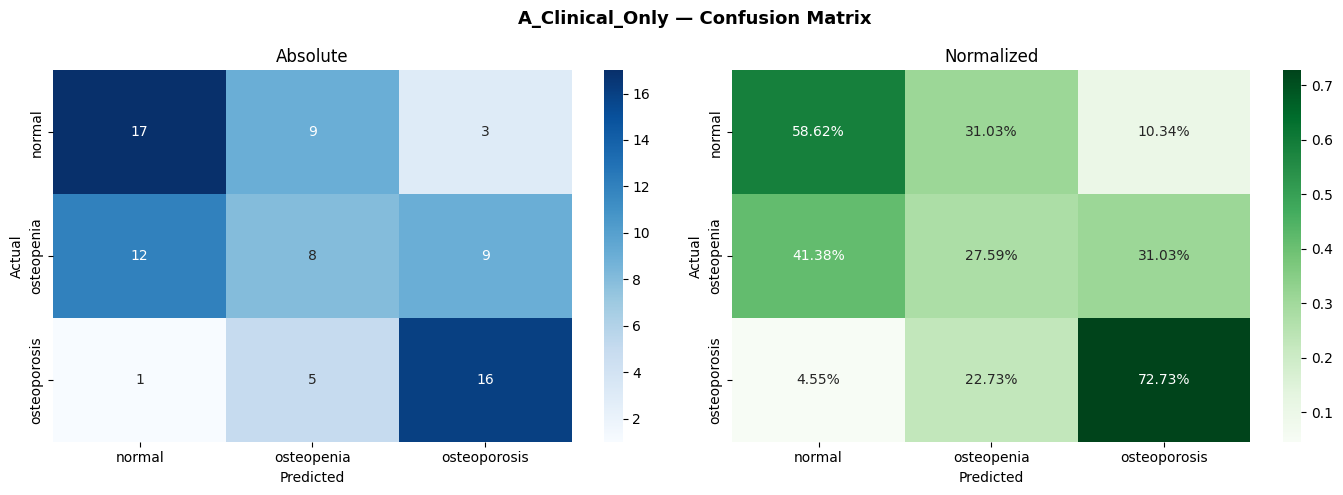

              precision    recall  f1-score   support

      normal       0.57      0.59      0.58        29
  osteopenia       0.36      0.28      0.31        29
osteoporosis       0.57      0.73      0.64        22

    accuracy                           0.51        80
   macro avg       0.50      0.53      0.51        80
weighted avg       0.49      0.51      0.50        80


  B_Image_Only


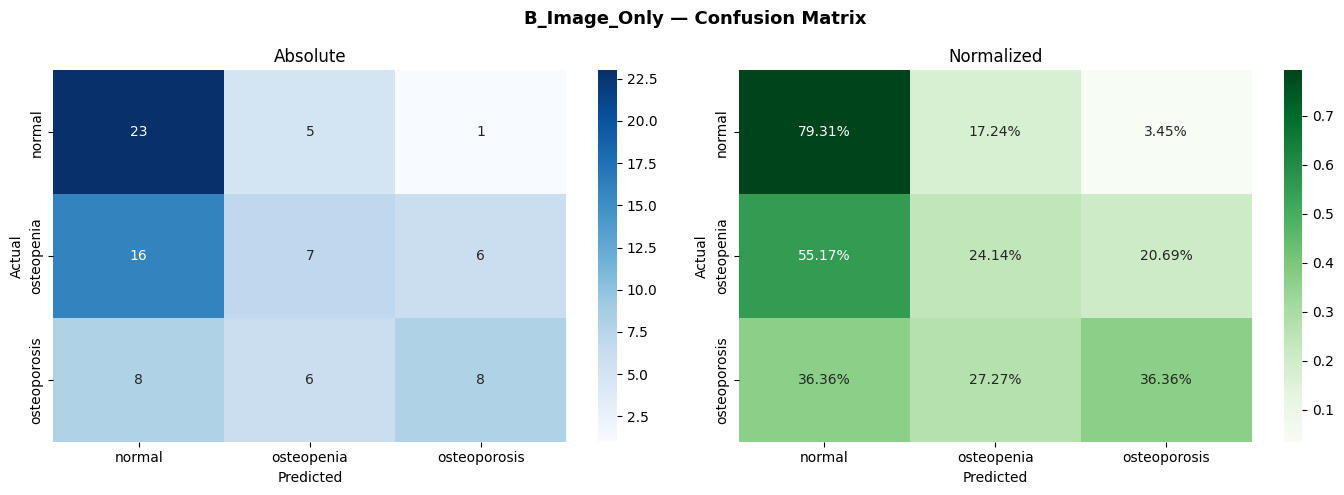

              precision    recall  f1-score   support

      normal       0.49      0.79      0.61        29
  osteopenia       0.39      0.24      0.30        29
osteoporosis       0.53      0.36      0.43        22

    accuracy                           0.47        80
   macro avg       0.47      0.47      0.45        80
weighted avg       0.47      0.47      0.45        80


  C_Multimodal_NoGating


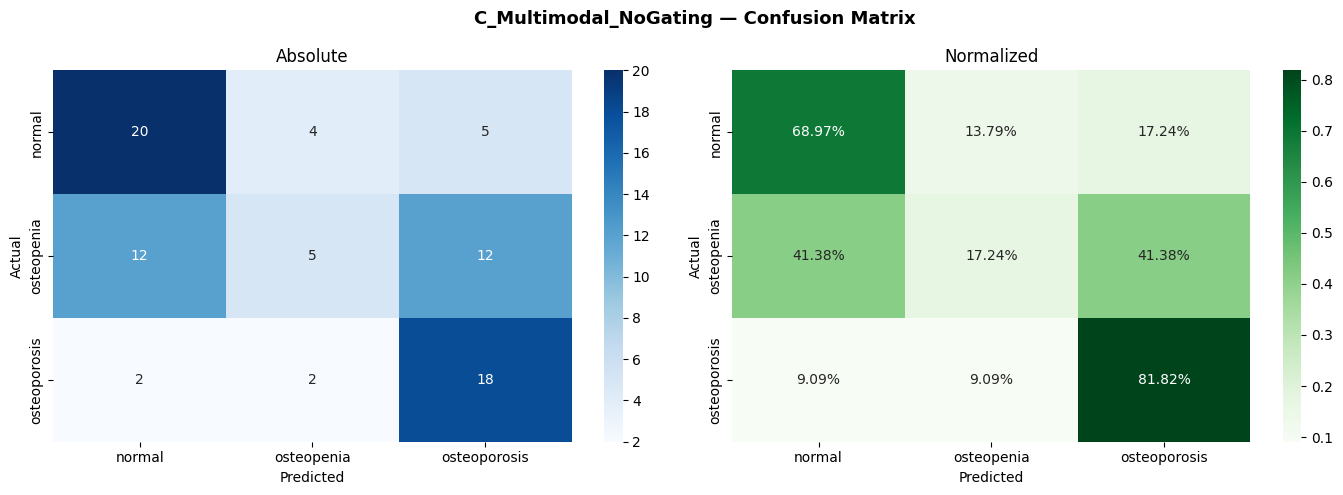

              precision    recall  f1-score   support

      normal       0.59      0.69      0.63        29
  osteopenia       0.45      0.17      0.25        29
osteoporosis       0.51      0.82      0.63        22

    accuracy                           0.54        80
   macro avg       0.52      0.56      0.51        80
weighted avg       0.52      0.54      0.49        80


  D_Multimodal_Gating


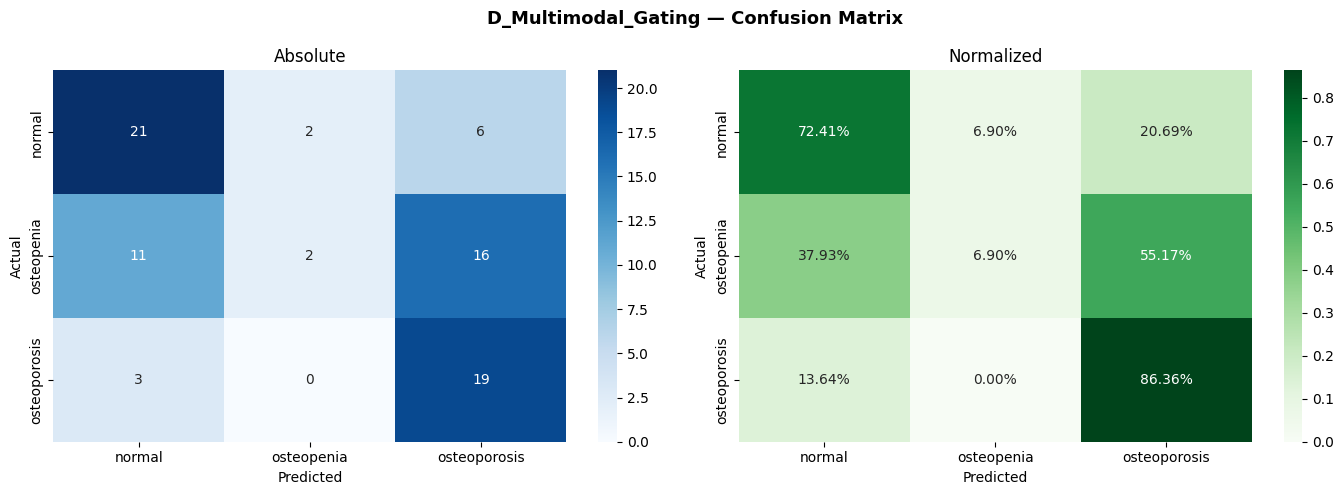

              precision    recall  f1-score   support

      normal       0.60      0.72      0.66        29
  osteopenia       0.50      0.07      0.12        29
osteoporosis       0.46      0.86      0.60        22

    accuracy                           0.53        80
   macro avg       0.52      0.55      0.46        80
weighted avg       0.53      0.53      0.45        80



In [40]:
# ══════════════════════════════════════════════════════════════════════════
#  CONFUSION MATRIX & CLASSIFICATION REPORT — Per Variant
# ══════════════════════════════════════════════════════════════════════════

for vname in ABLATION_VARIANTS:
    print(f'\n{"="*60}')
    print(f'  {vname}')
    print(f'{"="*60}')

    m = ablation_results[vname]
    y_true_all = np.array(m['y_true'])
    y_pred_all = np.array(m['y_pred'])

    cm = confusion_matrix(y_true_all, y_pred_all)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{vname} — Confusion Matrix', fontsize=13, fontweight='bold')
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax1)
    ax1.set_title('Absolute'); ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax2)
    ax2.set_title('Normalized'); ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
    plt.tight_layout(); plt.show()

    print(classification_report(y_true_all, y_pred_all, target_names=CLASS_NAMES))

### save splits, metadata dan preprocessor untuk deploy streamlit nanti
Menyimpan semua artefak yang diperlukan untuk deployment Streamlit:
- Split indices (train/val/test)
- Preprocessor (fitted sklearn ColumnTransformer)
- Metadata (class names, feature columns, image mode, dll.)
- Class weights


In [41]:
DEPLOY_DIR = Path('/kaggle/working/deploy_artifacts')
DEPLOY_DIR.mkdir(parents=True, exist_ok=True)

# Simpan ablation results
results_df.to_csv(str(DEPLOY_DIR / 'ablation_results.csv'), index=False)

save_d = {}
for vname in ABLATION_VARIANTS:
    m = ablation_results[vname]
    save_d[vname] = {
        k: float(v) for k, v in m.items()
        if k in ['accuracy', 'precision', 'recall', 'f1', 'auc']
    }
with open(str(DEPLOY_DIR / 'ablation_results.json'), 'w') as f:
    json.dump(save_d, f, indent=2)

# ── Simpan preprocessor tabular (WAJIB untuk inference konsisten) ────────
with open(str(DEPLOY_DIR / 'tab_preprocessor.pkl'), 'wb') as f:
    pickle.dump(preprocessor, f)

# ── Copy checkpoint model terbaik ke deploy dir ───────────────────────────
best_vname_deploy = max(ABLATION_VARIANTS.keys(), key=lambda v: ablation_results[v]['f1'])
import shutil
shutil.copy(str(MODEL_DIR / f'best_{best_vname_deploy}.keras'),
            str(DEPLOY_DIR / f'best_{best_vname_deploy}.keras'))

# Metadata
metadata = {
    'class_names': CLASS_NAMES,
    'label_map': LABEL_MAP,
    'n_classes': N_CLASSES,
    'img_size': list(IMG_SIZE),
    'image_mode': IMAGE_MODE,
    'num_features': num_feat_avail,
    'cat_features': cat_feat_avail,
    'variants': list(ABLATION_VARIANTS.keys()),
    'variant_config': {k: {'img': v['img'], 'tab': v['tab'], 'gate': v['gate']}
                        for k, v in ABLATION_VARIANTS.items()},
    'best_variant': best_vname_deploy,
    'best_variant_checkpoint': f'best_{best_vname_deploy}.keras',
    'dataset_size': len(df_clean),
    'gaussian_kernel_size': list(GAUSSIAN_KERNEL_SIZE),
    'gaussian_sigma': GAUSSIAN_SIGMA,
    'roi_config': ROI_CONFIG,
}
with open(str(DEPLOY_DIR / 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'✅ Deploy artifacts saved to: {DEPLOY_DIR}')
for p in sorted(DEPLOY_DIR.iterdir()):
    print(f'   {p.name:40} {p.stat().st_size/1e6:.2f} MB')
print(f'\n🏆 Best variant untuk deployment: {best_vname_deploy}')


✅ Deploy artifacts saved to: /kaggle/working/deploy_artifacts
   ablation_results.csv                     0.00 MB
   ablation_results.json                    0.00 MB
   best_A_Clinical_Only.keras               0.09 MB
   metadata.json                            0.00 MB
   tab_preprocessor.pkl                     0.00 MB

🏆 Best variant untuk deployment: A_Clinical_Only


### Interpretibilitas Model: Grad-CAM dan tambahan image segmentation menggunakan SAM

**Grad-CAM (Gradient-weighted Class Activation Mapping)**:
- Memvisualisasikan *region* di gambar yang paling berkontribusi pada prediksi model
- Diterapkan secara terpisah untuk **view AP** dan **view Lateral**


In [42]:
# ══════════════════════════════════════════════════════════════════════════
#  GRAD-CAM — Load Model TERLATIH dari Checkpoint (Tanpa Retrain)
# ══════════════════════════════════════════════════════════════════════════

# 1. Identifikasi best variant (single split, sudah dihitung di cell FINAL METRICS)
best_vname = max(ABLATION_VARIANTS.keys(),
                 key=lambda v: ablation_results[v]['f1'])
print(f'🏆 Best variant : {best_vname}  (F1={ablation_results[best_vname]["f1"]:.4f})')

# 2. Load checkpoint yang SUDAH dilatih di cell ablation loop — TIDAK retrain
ckpt_path = str(MODEL_DIR / f'best_{best_vname}.keras')
print(f'📂 Loading checkpoint: {ckpt_path}')

model_gc = keras.models.load_model(ckpt_path)
print(f'✅ Model dimuat tanpa training ulang.')

# 3. Gunakan test set yang sama dari ablation loop (single split, tanpa fold)
df_te_gc = df_test.reset_index(drop=True)
y_te_gc  = df_te_gc[label_col_raw].astype(int).values

vinfo = ABLATION_VARIANTS[best_vname]
if not vinfo['img'] and vinfo['tab']:
    te_gen_gc = ClinicalOnlyGenerator(X_tab_te, y_te_gc, shuffle=False)
elif vinfo['img'] and not vinfo['tab']:
    te_gen_gc = ImageOnlyGenerator(df_te_gc, y_te_gc, augment=False, shuffle=False, mode=IMAGE_MODE)
else:
    te_gen_gc = DualViewMultimodalGenerator(df_te_gc, X_tab_te, y_te_gc, augment=False, shuffle=False, mode=IMAGE_MODE)

# 4. Prediksi pakai model yang SUDAH terlatih
y_prob_gc = model_gc.predict(te_gen_gc, verbose=0)
y_pred_gc = np.argmax(y_prob_gc, axis=1)
df_te_gc = df_te_gc  # alias dipakai cell Grad-CAM berikutnya
print(f'✅ Test Acc (dari model tersimpan) = {accuracy_score(y_te_gc, y_pred_gc):.4f}')


🏆 Best variant : A_Clinical_Only  (F1=0.5100)
📂 Loading checkpoint: /kaggle/working/model_lumos_dual/best_A_Clinical_Only.keras
✅ Model dimuat tanpa training ulang.
✅ Test Acc (dari model tersimpan) = 0.6000


In [43]:
# 4. Grad-CAM Class
class DualViewGradCAM:
    def __init__(self, model):
        self.model = model
        # Cari backbone layers
        backbone_ap_layer  = None
        backbone_lat_layer = None
        for layer in model.layers:
            if hasattr(layer, 'layers'):  # sub-model
                name = layer.name.lower()
                if 'ap' in name:
                    backbone_ap_layer = layer
                elif 'lat' in name:
                    backbone_lat_layer = layer

        if backbone_ap_layer is None or backbone_lat_layer is None:
            raise ValueError('Backbone AP/LAT tidak ditemukan. Model ini mungkin Clinical-only.')

        # Cari last conv layer
        def find_last_conv(backbone):
            for layer in reversed(backbone.layers):
                if isinstance(layer, tf.keras.layers.Conv2D):
                    return layer.name
            return None

        last_conv_ap  = find_last_conv(backbone_ap_layer)
        last_conv_lat = find_last_conv(backbone_lat_layer)

        conv_out_ap  = backbone_ap_layer.get_layer(last_conv_ap).output
        conv_out_lat = backbone_lat_layer.get_layer(last_conv_lat).output

        self.grad_model_ap = keras.Model(
            inputs=backbone_ap_layer.input,
            outputs=[conv_out_ap, backbone_ap_layer.output])
        self.grad_model_lat = keras.Model(
            inputs=backbone_lat_layer.input,
            outputs=[conv_out_lat, backbone_lat_layer.output])

    def _compute_cam(self, grad_model, img_tensor, class_idx):
        with tf.GradientTape() as tape:
            img_t = tf.cast(img_tensor[np.newaxis, ...], tf.float32)
            conv_outputs, backbone_preds = grad_model(img_t)
            loss = backbone_preds[:, class_idx]
        grads = tape.gradient(loss, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_outputs = conv_outputs[0]
        cam = conv_outputs @ pooled_grads[..., tf.newaxis]
        cam = tf.squeeze(cam).numpy()
        cam = np.maximum(cam, 0)
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam

    def compute_dual_cam(self, ap_img, lat_img, class_idx):
        cam_ap  = self._compute_cam(self.grad_model_ap,  ap_img,  class_idx)
        cam_lat = self._compute_cam(self.grad_model_lat, lat_img, class_idx)
        return cam_ap, cam_lat

    @staticmethod
    def overlay_heatmap(img_rgb, cam, alpha=0.4):
        h, w = img_rgb.shape[:2]
        cam_resized = cv2.resize(cam, (w, h))
        heatmap = cv2.applyColorMap(
            (cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        img_norm = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min() + 1e-8)
        overlay = img_norm * (1 - alpha) + heatmap * alpha
        return np.clip(overlay, 0, 1)


# ── 5. Visualisasi (paste SEKALI SAJA) ────────────────────────────────
try:
    gradcam = DualViewGradCAM(model_gc)
    print('✅ Grad-CAM initialized')
except Exception as e:
    gradcam = None
    print(f'⚠️ Grad-CAM init gagal: {e}')

if gradcam is not None:
    # Pilih sampel: 1 benar per kelas + 1 salah
    np.random.seed(42)
    sample_indices = []

    for cls in range(N_CLASSES):
        correct = np.where((y_te_gc == cls) & (y_pred_gc == cls))[0]
        if len(correct) > 0:
            sample_indices.append(('correct', np.random.choice(correct)))
        wrong = np.where((y_te_gc == cls) & (y_pred_gc != cls))[0]
        if len(wrong) > 0:
            sample_indices.append(('wrong', np.random.choice(wrong)))

    for status, idx in sample_indices[:6]:
        row  = df_te_gc.iloc[idx]
        true_c = y_te_gc[idx]
        pred_c = y_pred_gc[idx]
        conf   = y_prob_gc[idx]

        ap_img  = preprocess_image(row['image_path_ap'],  IMAGE_MODE, IMG_SIZE, view='ap')
        lat_img = preprocess_image(row['image_path_lat'], IMAGE_MODE, IMG_SIZE, view='lat')

        try:
            cam_ap, cam_lat = gradcam.compute_dual_cam(ap_img, lat_img, pred_c)
            overlay_ap  = DualViewGradCAM.overlay_heatmap(ap_img,  cam_ap)
            overlay_lat = DualViewGradCAM.overlay_heatmap(lat_img, cam_lat)
        except Exception as e:
            print(f'⚠️ Grad-CAM gagal untuk idx {idx}: {e}')
            continue

        true_name = CLASS_NAMES[true_c]
        pred_name = CLASS_NAMES[pred_c]
        icon = '✅' if true_c == pred_c else '❌'

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(
            f'{icon} Patient {row["patient_id"]} | True: {true_name} | '
            f'Pred: {pred_name} | Conf: {conf[pred_c]:.1%}',
            fontsize=13, fontweight='bold',
            color='green' if true_c == pred_c else 'red')

        axes[0,0].imshow(ap_img[:,:,0], cmap='gray')
        axes[0,0].set_title('AP — Original')
        axes[0,1].imshow(overlay_ap)
        axes[0,1].set_title('AP — Grad-CAM')
        axes[1,0].imshow(lat_img[:,:,0], cmap='gray')
        axes[1,0].set_title('Lateral — Original')
        axes[1,1].imshow(overlay_lat)
        axes[1,1].set_title('Lateral — Grad-CAM')

        for ax in axes.flatten():
            ax.axis('off')

        conf_text = '  '.join([f'{CLASS_NAMES[i]}: {v:.1%}' for i, v in enumerate(conf)])
        fig.text(0.5, 0.01, f'Confidence: {conf_text}', ha='center', fontsize=10)
        plt.tight_layout(rect=[0, 0.03, 1, 1])
        plt.savefig(str(MODEL_DIR / f'gradcam_{row["patient_id"]}_{status}.png'),
                    dpi=150, bbox_inches='tight')
        plt.show()

    print(f'\n✅ Grad-CAM selesai. Gambar tersimpan di {MODEL_DIR}')

⚠️ Grad-CAM init gagal: Backbone AP/LAT tidak ditemukan. Model ini mungkin Clinical-only.


In [44]:
# ── Analisis Misklasifikasi ───────────────────────────────────────────
misclassified_idx = np.where(y_pred_gc != y_te_gc)[0]
print(f'Jumlah misklasifikasi: {len(misclassified_idx)} / {len(y_te_gc)} ({len(misclassified_idx)/len(y_te_gc)*100:.1f}%)')

if len(misclassified_idx) > 0:
    mis_df = pd.DataFrame({
        'patient_id': df_te_gc.iloc[misclassified_idx]['patient_id'].values,
        'true_label' : [CLASS_NAMES[y_te_gc[i]] for i in misclassified_idx],
        'pred_label' : [CLASS_NAMES[y_pred_gc[i]] for i in misclassified_idx],
        'confidence' : [y_prob_gc[i].max() for i in misclassified_idx],
    })
    mis_df = mis_df.sort_values('confidence', ascending=False)
    print('\nDaftar misklasifikasi (berurut berdasarkan confidence):')
    display(mis_df)

    # Confusion pattern
    print('\nPola confusion (True → Pred):')
    pattern = Counter(
        (CLASS_NAMES[y_te_gc[i]], CLASS_NAMES[y_pred_gc[i]]) for i in misclassified_idx
    )
    for (true_cls, pred_cls), count in pattern.most_common():
        print(f'  {true_cls:14} → {pred_cls:14}: {count} kasus')

Jumlah misklasifikasi: 32 / 80 (40.0%)

Daftar misklasifikasi (berurut berdasarkan confidence):


,patient_id,true_label,pred_label,confidence
0,693,osteopenia,normal,0.539801
15,223,normal,osteopenia,0.530349
26,507,normal,osteopenia,0.516776
8,670,normal,osteopenia,0.506792
1,727,osteopenia,osteoporosis,0.490982
20,125,osteopenia,osteoporosis,0.473229
30,230,osteopenia,normal,0.457816
12,639,osteopenia,osteoporosis,0.456866
9,782,osteoporosis,normal,0.451909
24,80,osteopenia,osteoporosis,0.450492



Pola confusion (True → Pred):
  osteopenia     → osteoporosis  : 9 kasus
  osteopenia     → normal        : 8 kasus
  normal         → osteopenia    : 6 kasus
  normal         → osteoporosis  : 4 kasus
  osteoporosis   → osteopenia    : 4 kasus
  osteoporosis   → normal        : 1 kasus


In [45]:
print('='*70)
print('RINGKASAN EKSPERIMEN — ABLATION STUDY (Single 80/10/10 Split)')
print('='*70)
print(f'Arsitektur      : Dual-View ResNet50 (AP + Lateral) × Tabular MLP')
print(f'Ablation        : 4 varian (Clinical, Image, NoGate, Gate)')
print(f'Fusion          : Late Fusion + Attention-Gating')
print(f'Preprocessing   : Gaussian → ROI Crop (L1-L4) → Bone Enhancement')
print(f'Augmentasi      : Rotation ±40° | Shift ±0.2 | Shear 0.2 | H-Flip')
print(f'Imbalance       : Class Weights (balanced)')
print(f'Validasi        : Single 80/10/10 Stratified Split')
print(f'Fine-Tuning     : 2-stage ({EPOCHS_STAGE1}+{EPOCHS_STAGE2} epochs)')
print(f'Dataset         : {len(df_clean):,} pasien valid')
print()

for vname in ABLATION_VARIANTS:
    m = ablation_results[vname]
    print(f'  {vname:30}  Acc={m["accuracy"]:.4f}  F1={m["f1"]:.4f}  AUC={m["auc"]:.4f}')

best_vname = max(ABLATION_VARIANTS.keys(),
                 key=lambda v: ablation_results[v]['f1'])
print(f'\n🏆 Best: {best_vname}')
print(f'Artefak: {MODEL_DIR}')
print('='*70)

RINGKASAN EKSPERIMEN — ABLATION STUDY (Single 80/10/10 Split)
Arsitektur      : Dual-View ResNet50 (AP + Lateral) × Tabular MLP
Ablation        : 4 varian (Clinical, Image, NoGate, Gate)
Fusion          : Late Fusion + Attention-Gating
Preprocessing   : Gaussian → ROI Crop (L1-L4) → Bone Enhancement
Augmentasi      : Rotation ±40° | Shift ±0.2 | Shear 0.2 | H-Flip
Imbalance       : Class Weights (balanced)
Validasi        : Single 80/10/10 Stratified Split
Fine-Tuning     : 2-stage (35+35 epochs)
Dataset         : 793 pasien valid

  A_Clinical_Only                 Acc=0.5125  F1=0.5100  AUC=0.7226
  B_Image_Only                    Acc=0.4750  F1=0.4452  AUC=0.6320
  C_Multimodal_NoGating           Acc=0.5375  F1=0.5055  AUC=0.7478
  D_Multimodal_Gating             Acc=0.5250  F1=0.4602  AUC=0.7697

🏆 Best: A_Clinical_Only
Artefak: /kaggle/working/model_lumos_dual


# SHAP Analysis — Fitur Tabular Terpilih
Interpretasi kontribusi tiap fitur klinis (`num_feat_avail` + `cat_feat_avail`) terhadap prediksi model **best variant**.

- Kalau best variant **Clinical-Only** → SHAP langsung dihitung dari model (cepat).
- Kalau best variant **multimodal** (pakai citra juga) → citra tiap sampel **dibekukan** ke nilai aslinya, hanya fitur tabular yang diperturbasi — supaya kontribusi yang diukur murni dari sisi tabular.
- Kalau best variant **Image-Only** → SHAP tabular tidak relevan (model tidak menerima input tabular sama sekali).

In [ ]:
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'shap'], check=True)
    import shap

uses_img_best = ABLATION_VARIANTS[best_vname]['img']
uses_tab_best = ABLATION_VARIANTS[best_vname]['tab']

if not uses_tab_best:
    print(f'⚠️ Best variant "{best_vname}" tidak memakai input tabular — SHAP tabular dilewati.')
else:
    feature_names_shap = preprocessor.get_feature_names_out()
    print(f'Fitur tabular terpilih ({len(feature_names_shap)}): {list(feature_names_shap)}')

    N_EXPLAIN = min(40, len(df_te_gc))
    np.random.seed(RANDOM_STATE)
    explain_idx = np.random.choice(len(df_te_gc), N_EXPLAIN, replace=False)

    # Baseline / background tabular — median training set
    X_tab_bg = np.median(X_tab_tr, axis=0, keepdims=True)

    if not uses_img_best:
        # ── Clinical-only: model murni tabular, SHAP langsung & cepat ────────────────────────────────────────────────────────────
        def predict_fn(x):
            return model_gc.predict(x, verbose=0)

        explainer = shap.KernelExplainer(predict_fn, X_tab_bg)
        sv_raw = explainer.shap_values(X_tab_te[explain_idx], nsamples=200)
        shap_values = sv_raw if isinstance(sv_raw, list) else [sv_raw[..., c] for c in range(N_CLASSES)]
    else:
        # ── Multimodal: citra dibekukan per-sampel, hanya tabular diperturbasi ───────────────────────────────────
        shap_values_per_sample = []
        for i in tqdm(explain_idx, desc='SHAP per sampel (multimodal)'):
            row = df_te_gc.iloc[i]
            ap_img  = preprocess_image(row['image_path_ap'],  IMAGE_MODE, IMG_SIZE, view='ap')
            lat_img = preprocess_image(row['image_path_lat'], IMAGE_MODE, IMG_SIZE, view='lat')

            def predict_fn(tab_batch, _ap=ap_img, _lat=lat_img):
                n = tab_batch.shape[0]
                ap_batch  = np.repeat(_ap[None, ...],  n, axis=0)
                lat_batch = np.repeat(_lat[None, ...], n, axis=0)
                return model_gc.predict([ap_batch, lat_batch, tab_batch], verbose=0)

            explainer = shap.KernelExplainer(predict_fn, X_tab_bg)
            sv = explainer.shap_values(X_tab_te[i:i+1], nsamples=100)
            sv = sv if isinstance(sv, list) else [sv[..., c] for c in range(N_CLASSES)]
            shap_values_per_sample.append(sv)

        shap_values = [
            np.concatenate([sv[c] for sv in shap_values_per_sample], axis=0)
            for c in range(N_CLASSES)
        ]

    X_tab_explain = X_tab_te[explain_idx]

    # ── Summary plot per kelas ──────────────────────────────────────────────────────
    for c in range(N_CLASSES):
        print(f'\n=== SHAP Summary — Kelas: {CLASS_NAMES[c]} ===')
        shap.summary_plot(shap_values[c], X_tab_explain,
                          feature_names=feature_names_shap, show=False)
        plt.title(f'SHAP Summary — {CLASS_NAMES[c]} ({best_vname})')
        plt.tight_layout()
        plt.savefig(str(MODEL_DIR / f'shap_summary_{CLASS_NAMES[c]}.png'), dpi=150, bbox_inches='tight')
        plt.show()

    # ── Global feature importance (mean |SHAP| rata-rata semua kelas) ───────────────────
    mean_abs_shap = np.mean([np.abs(shap_values[c]).mean(axis=0) for c in range(N_CLASSES)], axis=0)
    imp_df = pd.DataFrame({'feature': feature_names_shap, 'mean_abs_shap': mean_abs_shap})
    imp_df = imp_df.sort_values('mean_abs_shap', ascending=True)

    fig, ax = plt.subplots(figsize=(8, max(4, len(imp_df) * 0.4)))
    ax.barh(imp_df['feature'], imp_df['mean_abs_shap'], color='#3498db', edgecolor='black')
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(f'Global Feature Importance — {best_vname} (rata-rata semua kelas)')
    plt.tight_layout()
    plt.savefig(str(MODEL_DIR / 'shap_global_importance.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print('\nRanking fitur (mean |SHAP value|, semua kelas):')
    display(imp_df.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True))

    # ── Simpan hasil SHAP ke deploy artifacts ──────────────────────────────────────────────
    imp_df.sort_values('mean_abs_shap', ascending=False).to_csv(
        str(MODEL_DIR / 'shap_feature_importance.csv'), index=False)
    print(f'\n✅ SHAP artifacts tersimpan di: {MODEL_DIR}')

# Export Preprocessing Module
Tulis `preprocessing.py` (identik dengan pipeline training) ke `deploy_artifacts/` supaya inference (Streamlit dsb.) selalu match dengan training — satu sumber kebenaran, gak ada duplikasi/drift kode.

In [ ]:
PREPROCESSING_MODULE_CODE = r"""
LUMOS — Preprocessing Module
Persis sama dengan pipeline training di notebook (cell ROI Configuration / Gaussian / Bone Enhancement).
Dipakai bareng oleh: notebook (source of truth) & streamlit_app.py (inference).
"""

import cv2
import numpy as np
import pydicom


# ══════════════════════════════════════════════════════════════════════════
#  CONFIG (harus sama persis dengan notebook cell config)
# ══════════════════════════════════════════════════════════════════════════
IMG_H, IMG_W = 224, 224
IMG_SIZE = (IMG_H, IMG_W)

GAUSSIAN_KERNEL_SIZE = (5, 5)
GAUSSIAN_SIGMA = 1.0

ROI_CONFIG = {
    "ap":  {"top": 0.12, "bottom": 0.98, "left": 0.22, "right": 0.78},
    "lat": {"top": 0.12, "bottom": 0.98, "left": 0.12, "right": 0.85},
}

NUM_FEATURES = ["age", "height", "weight", "bmi"]
CATEGORICAL_FEATURES = ["gender"]

CLASS_NAMES = ["normal", "osteopenia", "osteoporosis"]
LABEL_MAP = {"normal": 0, "osteopenia": 1, "osteoporosis": 2}


# ══════════════════════════════════════════════════════════════════════════
#  IMAGE LOADING
# ══════════════════════════════════════════════════════════════════════════
def load_image_array(path: str, mode: str = "npy") -> np.ndarray:
    """Load gambar dari .npy atau .dcm dan kembalikan array 2D grayscale."""
    if mode == "npy":
        arr = np.load(path)
        if arr.ndim == 3:
            arr = arr[arr.shape[0] // 2]
    else:
        ds = pydicom.dcmread(path, force=True)
        arr = ds.pixel_array
    return arr.astype(np.float32)


def load_image_array_from_bytes(file_bytes: bytes) -> np.ndarray:
    """Load gambar dari file upload biasa (png/jpg) untuk keperluan deployment."""
    buf = np.asarray(bytearray(file_bytes), dtype=np.uint8)
    arr = cv2.imdecode(buf, cv2.IMREAD_GRAYSCALE)
    return arr.astype(np.float32)


# ══════════════════════════════════════════════════════════════════════════
#  PIPELINE STEPS — identik dengan notebook
# ══════════════════════════════════════════════════════════════════════════
def apply_gaussian_filter(arr, ksize=GAUSSIAN_KERNEL_SIZE, sigma=GAUSSIAN_SIGMA):
    """Gaussian Blur untuk noise reduction sensor DXA."""
    arr_norm = cv2.normalize(arr, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return cv2.GaussianBlur(arr_norm, ksize, sigma).astype(np.float32)


def crop_lumbar_roi(arr, view="ap"):
    """Crop ROI vertebra lumbal L1-L4 (koordinat persentase)."""
    cfg = ROI_CONFIG.get(view, ROI_CONFIG["ap"])
    h, w = arr.shape[:2]
    r0, r1 = int(h * cfg["top"]), int(h * cfg["bottom"])
    c0, c1 = int(w * cfg["left"]), int(w * cfg["right"])
    cropped = arr[r0:r1, c0:c1]
    return cropped if cropped.size > 0 else arr


def enhance_bone_region(arr, clip_limit=2.5, tile_size=(8, 8), mask_blend=0.65):
    """CLAHE + Otsu masking: tingkatkan kontras tulang, lemahkan soft tissue."""
    if arr.dtype != np.uint8:
        arr_u8 = cv2.normalize(arr, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    else:
        arr_u8 = arr.copy()
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    enhanced = clahe.apply(arr_u8)
    _, bone_mask = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    bone_mask = cv2.morphologyEx(bone_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    bone_mask = cv2.morphologyEx(bone_mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask_norm = bone_mask.astype(np.float32) / 255.0
    soft_blend = mask_norm * mask_blend + (1.0 - mask_blend)
    return enhanced.astype(np.float32) * soft_blend


def preprocess_image(path, mode="npy", target_size=IMG_SIZE,
                      view="ap", apply_filter=True,
                      apply_roi=True, apply_bone=True):
    """Pipeline lengkap (dari path file, dipakai saat training):
    Load -> Gaussian -> ROI Crop -> Bone Enhancement -> Resize -> Normalize -> RGB
    """
    arr = load_image_array(path, mode)
    return _run_pipeline(arr, target_size, view, apply_filter, apply_roi, apply_bone)


def preprocess_uploaded_image(file_bytes, target_size=IMG_SIZE, view="ap",
                               apply_filter=True, apply_roi=True, apply_bone=True):
    """Pipeline lengkap dari bytes upload (dipakai saat inference/Streamlit)."""
    arr = load_image_array_from_bytes(file_bytes)
    return _run_pipeline(arr, target_size, view, apply_filter, apply_roi, apply_bone)


def _run_pipeline(arr, target_size, view, apply_filter, apply_roi, apply_bone):
    if apply_filter:
        arr = apply_gaussian_filter(arr)
    if apply_roi:
        arr = crop_lumbar_roi(arr, view=view)
    if apply_bone:
        arr = enhance_bone_region(arr)
    arr_resized = cv2.resize(arr, target_size, interpolation=cv2.INTER_LINEAR)
    arr_norm = arr_resized / 255.0 if arr_resized.max() > 1.0 else arr_resized
    arr_norm = arr_norm.astype(np.float32)
    if arr_norm.ndim == 2:
        arr_rgb = np.stack([arr_norm] * 3, axis=-1)
    else:
        arr_rgb = arr_norm
    return arr_rgb




preproc_path = DEPLOY_DIR / 'preprocessing.py'
with open(str(preproc_path), 'w') as f:
    f.write(PREPROCESSING_MODULE_CODE)

print(f'\u2705 preprocessing.py exported to: {preproc_path}')
print(f'   Size: {preproc_path.stat().st_size/1024:.1f} KB')
print('\nIsi deploy_artifacts/ sekarang:')
for p in sorted(DEPLOY_DIR.iterdir()):
    print(f'   {p.name:40} {p.stat().st_size/1e6:.3f} MB')